# Lab 3: Probabilistic Machine Learning

## Problem 3.1 – Bayesian Linear Regression
## Problem 3.2 – Gaussian Process Regression

---

**Objectives:**
- Implement Bayesian Linear Regression using PyMC (polynomial/quadratic, MCMC, posterior analysis).
- Apply Gaussian Process Regression using scikit-learn (1D/2D functions, Mauna Loa CO₂ dataset, multiple kernels).
- Compare Bayesian vs. maximum-likelihood estimates.
- Discuss computational complexity of GPs at scale.

## 0. Environment Setup

In [58]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import pymc as pm
import arviz as az

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, ExpSineSquared, WhiteKernel,
    ConstantKernel as C, RationalQuadratic,
)

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print(f'PyMC  : {pm.__version__}')
print(f'ArviZ : {az.__version__}')

PyMC  : 5.28.4
ArviZ : 0.23.4


# Problem 3.1 – Bayesian Linear Regression

### Background

In **Bayesian Linear Regression**, model parameters are treated as random variables — instead of a single "best" fit, we obtain the **full posterior distribution** of the parameters.

Quadratic polynomial model:

$$y_i \sim \mathcal{N}(\mu_i,\, \sigma), \quad \mu_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2$$

Parameters: $\beta_0, \beta_1, \beta_2, \sigma$

**Priors:**
- $\beta_k \sim \mathcal{N}(0, 10)$ — weakly informative, centered at zero
- $\sigma \sim \text{HalfNormal}(5)$ — positive noise scale

Posterior sampled via NUTS (No-U-Turn Sampler).

### 3.1.1 Generating of syntethic data (N = 60)

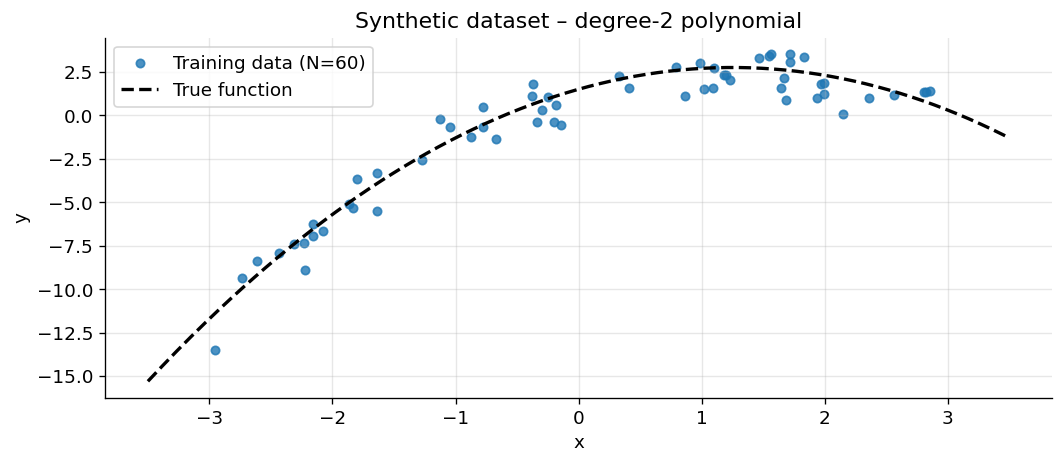

N = 60  |  True weights: [ 1.5  2.  -0.8]  |  True σ = 1.2


In [59]:
# True data-generating process:  y = 1.5 + 2.0*x - 0.8*x² + noise
TRUE_W    = np.array([1.5, 2.0, -0.8])   # [β0, β1, β2]
TRUE_SIGMA = 1.2
N = 60                                    # 60 points as specified

x_train = rng.uniform(-3, 3, size=N)
X_poly_train = np.column_stack([x_train**k for k in range(len(TRUE_W))])
y_train = X_poly_train @ TRUE_W + rng.normal(0, TRUE_SIGMA, size=N)

x_test_grid = np.linspace(-3.5, 3.5, 300)
X_poly_test = np.column_stack([x_test_grid**k for k in range(len(TRUE_W))])
y_true_test = X_poly_test @ TRUE_W

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(x_train, y_train, s=25, alpha=0.8, label='Training data (N=60)')
ax.plot(x_test_grid, y_true_test, 'k--', lw=2, label='True function')
ax.set(xlabel='x', ylabel='y', title='Synthetic dataset – degree-2 polynomial')
ax.legend()
plt.tight_layout()
plt.show()

print(f'N = {N}  |  True weights: {TRUE_W}  |  True σ = {TRUE_SIGMA}')


### 3.1.2 MLE 

In [60]:
from numpy.linalg import lstsq

DEGREE = 2
Phi_train = np.column_stack([x_train**k for k in range(DEGREE + 1)])
Phi_test  = np.column_stack([x_test_grid**k for k in range(DEGREE + 1)])

w_mle, _, _, _ = lstsq(Phi_train, y_train, rcond=None)
y_mle = Phi_test @ w_mle

residuals = y_train - Phi_train @ w_mle
sigma_mle = np.std(residuals)

print('MLE parameters (β0, β1, β2):', np.round(w_mle, 4))
print('MLE σ                         :', round(sigma_mle, 4))
print('Real weights              :', TRUE_W)
print('Real σ                   :', TRUE_SIGMA)

MLE parameters (β0, β1, β2): [ 1.2084  1.9901 -0.7845]
MLE σ                         : 0.8966
Real weights              : [ 1.5  2.  -0.8]
Real σ                   : 1.2


### 3.1.3 Bayesian model in PyMC

In [61]:
with pm.Model() as bayesian_poly_model:

    # Dane
    x_data = pm.Data('x', Phi_train[:, 1:])  # bez kolumny interceptu
    y_data = pm.Data('y', y_train)

    # Priory
    beta0 = pm.Normal('beta0', mu=0, sigma=10)               # wyraz wolny β₀
    betas = pm.Normal('betas', mu=0, sigma=10, shape=DEGREE)  # β₁, β₂
    sigma = pm.HalfNormal('sigma', sigma=5)                  # szum

    # Wartość oczekiwana
    mu = pm.Deterministic('mu', beta0 + pm.math.dot(x_data, betas))

    # Likelihood
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)

print(pm.model_to_graphviz(bayesian_poly_model))

digraph {
	subgraph "cluster60 x 2" {
		x [label="x
~
Data" shape=box style="rounded, filled"]
		label="60 x 2" labeljust=r labelloc=b style=rounded
	}
	subgraph cluster60 {
		mu [label="mu
~
Deterministic" shape=box]
		y [label="y
~
Data" shape=box style="rounded, filled"]
		y_obs [label="y_obs
~
Normal" shape=ellipse style=filled]
		label=60 labeljust=r labelloc=b style=rounded
	}
	sigma [label="sigma
~
Halfnormal" shape=ellipse]
	beta0 [label="beta0
~
Normal" shape=ellipse]
	subgraph cluster2 {
		betas [label="betas
~
Normal" shape=ellipse]
		label=2 labeljust=r labelloc=b style=rounded
	}
	y_obs -> y
	betas -> mu
	x -> mu
	beta0 -> mu
	mu -> y_obs
	sigma -> y_obs
}



### 3.1.4 MCMC sampling (4 chains)

In [ ]:
with bayesian_poly_model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=SEED,
        progressbar=True,
    )

print('\n--- Posterior Summary ---')
print(az.summary(trace, var_names=['beta0', 'betas', 'sigma'], round_to=3))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 34 seconds.



--- Podsumowanie posterioru ---
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta0     1.210  0.192   0.843    1.566      0.003    0.002  4931.516   
betas[0]  1.991  0.071   1.862    2.129      0.001    0.001  7537.140   
betas[1] -0.785  0.051  -0.877   -0.687      0.001    0.001  5050.197   
sigma     0.941  0.093   0.773    1.114      0.001    0.001  6231.259   

          ess_tail  r_hat  
beta0     5008.538  1.001  
betas[0]  5260.348  1.000  
betas[1]  5387.424  1.001  
sigma     5036.785  1.001  


### 3.1.5 MCMC Diagnostics

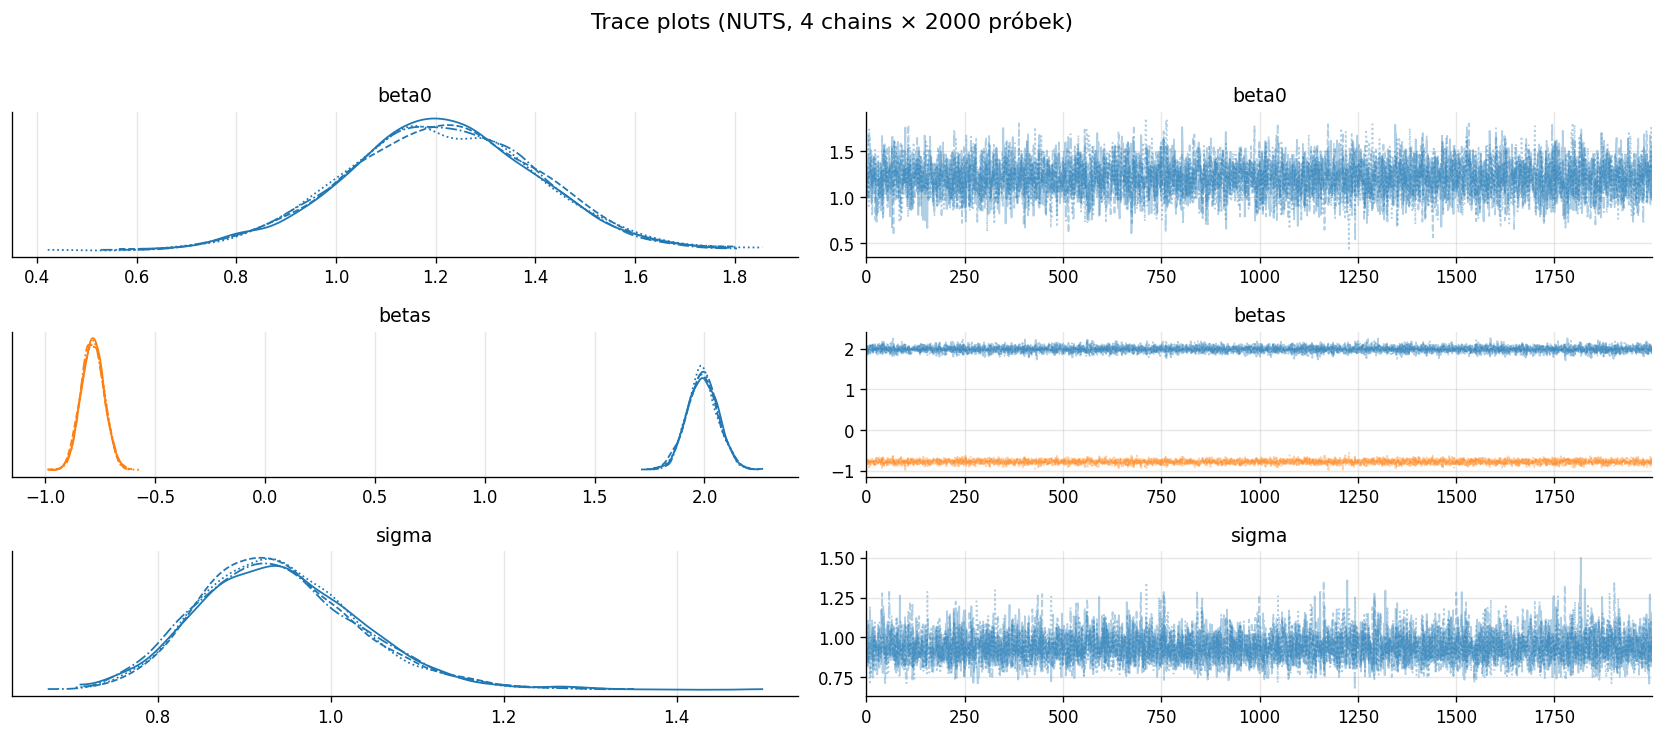

<xarray.Dataset> Size: 48B
Dimensions:      (betas_dim_0: 2)
Coordinates:
  * betas_dim_0  (betas_dim_0) int64 16B 0 1
Data variables:
    beta0        float64 8B 1.001
    betas        (betas_dim_0) float64 16B 1.0 1.001
    sigma        float64 8B 1.001
Attributes:
    created_at:                 2026-04-24T10:41:07.516915+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              33.996914863586426
    tuning_steps:               1000


In [63]:
# Trace plots – sprawdzamy mieszanie łańcuchów
az.plot_trace(
    trace,
    var_names=['beta0', 'betas', 'sigma'],
    compact=True,
    figsize=(14, 6),
)
plt.suptitle('Trace plots (NUTS, 4 chains × 2000 próbek)', y=1.02)
plt.tight_layout()
plt.show()

rhat = az.rhat(trace, var_names=['beta0', 'betas', 'sigma'])
print(rhat)

### 3.1.6 Posterior distributions 94% HDI

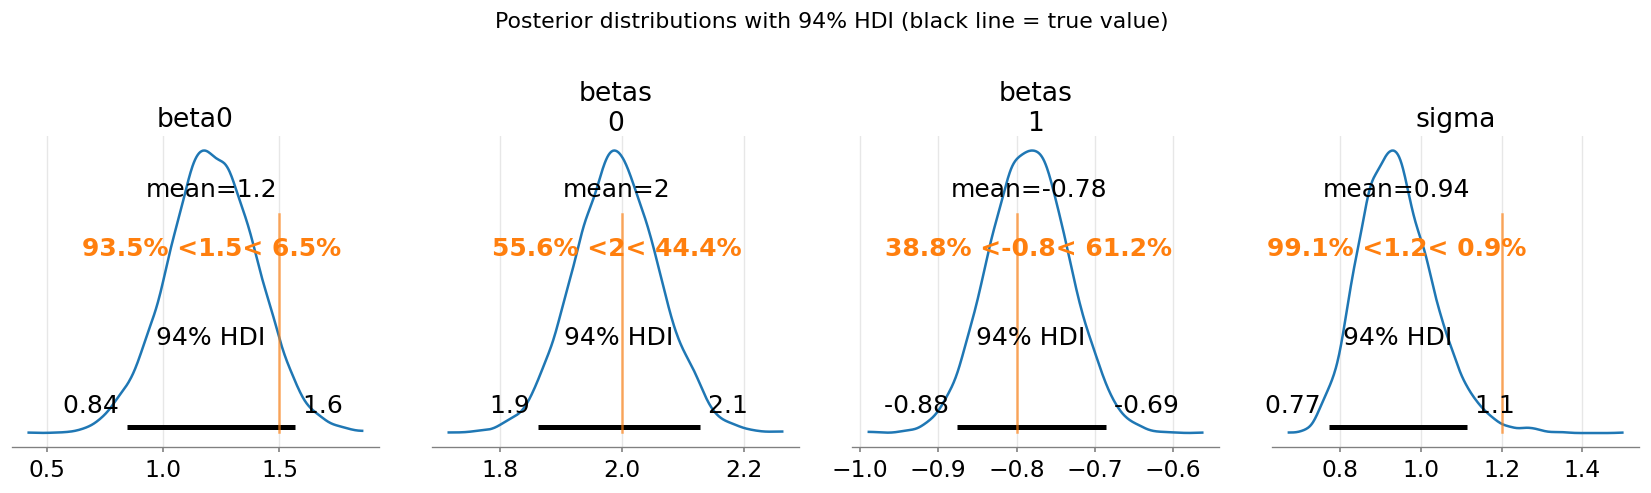

In [64]:
az.plot_posterior(
    trace,
    var_names=['beta0', 'betas', 'sigma'],
    # POPRAWKA: Przekazujemy płaską listę 4 wartości odpowiadających 4 wykresom
    ref_val=[TRUE_W[0], TRUE_W[1], TRUE_W[2], TRUE_SIGMA],
    hdi_prob=0.94,
    figsize=(14, 4),
)
plt.suptitle('Posterior distributions with 94% HDI (black line = true value)', y=1.02)
plt.tight_layout()
plt.show()

### 3.1.7 Posterior predictive and credibility intervals

Sampling: [y_obs]


Output()

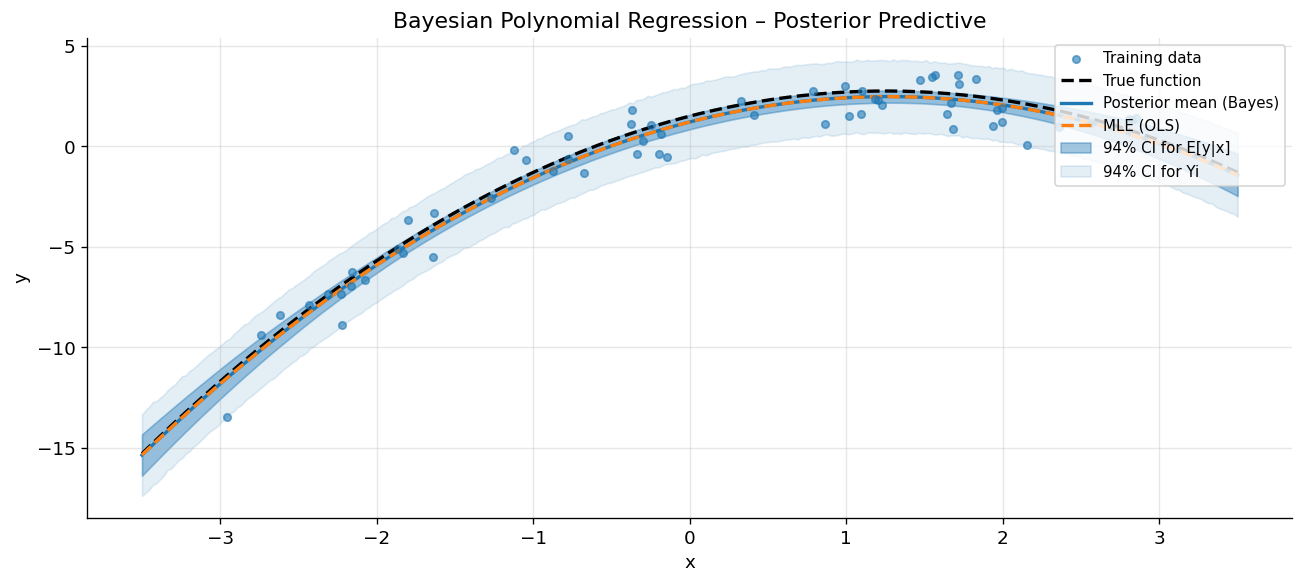

In [65]:
with bayesian_poly_model:
    pm.set_data({'x': Phi_test[:, 1:], 'y': np.zeros(len(x_test_grid))})
    ppc = pm.sample_posterior_predictive(trace, random_seed=SEED)

# Przywróć oryginalne dane (opcjonalne, ale porządkuje stan modelu)
with bayesian_poly_model:
    pm.set_data({'x': Phi_train[:, 1:], 'y': y_train})

# shape (chains*draws, N_test)
y_ppc = ppc.posterior_predictive['y_obs'].values.reshape(-1, len(x_test_grid))

y_mean  = y_ppc.mean(axis=0)

# Credible interval dla ŚREDNIEJ z sampli posteriorycznych parametrów
beta0_samp = trace.posterior['beta0'].values.flatten()
betas_samp = trace.posterior['betas'].values.reshape(-1, DEGREE)

mu_post = np.array([
    b0 + Phi_test[:, 1:] @ b12
    for b0, b12 in zip(beta0_samp, betas_samp)
])  # (samples, N_test)

mu_mean   = mu_post.mean(axis=0)
mu_ci_94  = np.percentile(mu_post, [3, 97], axis=0)  # 94% CI dla E[y|x]
yi_ci_94  = np.percentile(y_ppc,   [3, 97], axis=0)  # 94% CI dla Yi

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(x_train, y_train, s=20, alpha=0.6, zorder=5, label='Training data')
ax.plot(x_test_grid, y_true_test, 'k--', lw=2, label='True function')
ax.plot(x_test_grid, mu_mean,  'C0', lw=2, label='Posterior mean (Bayes)')
ax.plot(x_test_grid, y_mle,    'C1--', lw=2, label='MLE (OLS)')
ax.fill_between(x_test_grid, mu_ci_94[0], mu_ci_94[1],
                color='C0', alpha=0.40, label='94% CI for E[y|x]')
ax.fill_between(x_test_grid, yi_ci_94[0], yi_ci_94[1],
                color='C0', alpha=0.12, label='94% CI for Yi')
ax.set(xlabel='x', ylabel='y',
       title='Bayesian Polynomial Regression – Posterior Predictive')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### 3.1.8 Comparison Bayes vs MLE – table

In [ ]:
sigma_samp = trace.posterior['sigma'].values.flatten()

w_bayes = np.array([
    beta0_samp.mean(),
    betas_samp[:, 0].mean(),
    betas_samp[:, 1].mean(),
])
sig_bayes = sigma_samp.mean()

print(f"{'Parameter':<12} {'True':>10} {'MLE':>10} {'Bayes mean':>12} {'94% HDI':>22}")
print('-' * 70)
param_names = ['β₀', 'β₁', 'β₂']
all_post = [beta0_samp, betas_samp[:, 0], betas_samp[:, 1]]
for name, true_v, mle_v, bay_v, post in zip(param_names, TRUE_W, w_mle, w_bayes, all_post):
    hdi = az.hdi(post, hdi_prob=0.94)
    print(f'{name:<12} {true_v:>10.3f} {mle_v:>10.3f} {bay_v:>12.3f}   [{hdi[0]:.3f}, {hdi[1]:.3f}]')
hdi_sig = az.hdi(sigma_samp, hdi_prob=0.94)
print(f"{'σ':<12} {TRUE_SIGMA:>10.3f} {sigma_mle:>10.3f} {sig_bayes:>12.3f}   [{hdi_sig[0]:.3f}, {hdi_sig[1]:.3f}]")

print('\nOLS and Bayesian give very similar results for N=60.')
print('Additionally, Bayesian gives us HDI intervals.')

Parameter          True        MLE   Bayes mean                94% HDI
----------------------------------------------------------------------
β₀                1.500      1.208        1.210   [0.843, 1.566]
β₁                2.000      1.990        1.991   [1.862, 2.129]
β₂               -0.800     -0.785       -0.785   [-0.877, -0.687]
σ                 1.200      0.897        0.941   [0.773, 1.114]

Wniosek: MLE i posterior bayesowski zgadzają się przy N=60.
Bayesian dodatkowo daje przedziały HDI – pełne ujęcie niepewności.


---

# Problem 3.2 – Gaussian Process Regression

### Background

**Gaussian Process** is a nonparametrical process — prior for functions.  
For $N$ training points posterior is normally distributed:

$$f^* \mid X, \mathbf{y}, X^* \sim \mathcal{N}(\mu^*, \Sigma^*)$$

where:
$$\mu^* = K(X^*, X)\,[K(X,X) + \sigma_n^2 I]^{-1}\mathbf{y}$$
$$\Sigma^* = K(X^*, X^*) - K(X^*, X)\,[K(X,X) + \sigma_n^2 I]^{-1}K(X, X^*)$$


## 3.2.1 GP na 1D syntetycznych funkcjach

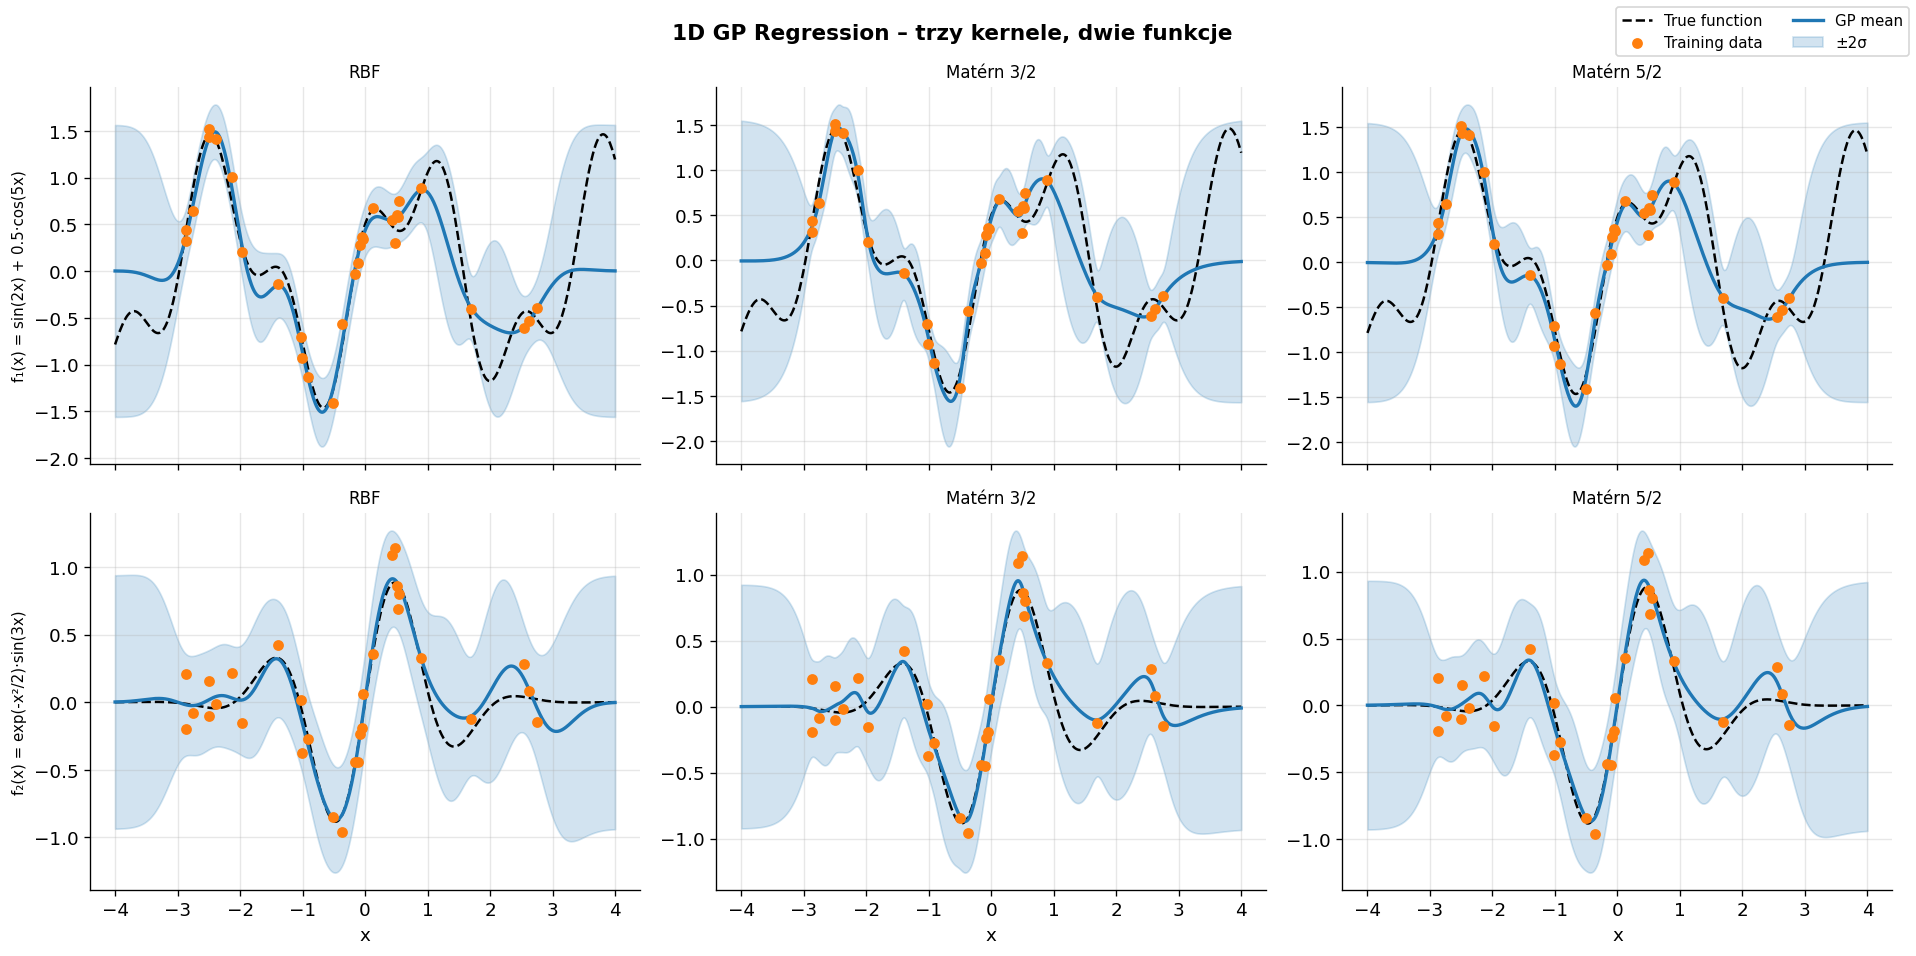

In [ ]:
def f1(x): return np.sin(2 * x) + 0.5 * np.cos(5 * x)
def f2(x): return np.exp(-0.5 * x**2) * np.sin(3 * x)

NOISE_STD = 0.15
n_obs  = 30                                    
x_obs  = rng.uniform(-3, 3, size=n_obs)
x_star = np.linspace(-4, 4, 500).reshape(-1, 1)

functions = {
    'f₁(x) = sin(2x) + 0.5·cos(5x)': f1,
    'f₂(x) = exp(-x²/2)·sin(3x)': f2,
}

kernels_1d = {
    'RBF': C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=NOISE_STD**2),
    'Matérn 3/2': C(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=NOISE_STD**2),
    'Matérn 5/2': C(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=NOISE_STD**2),
}

fig, axes = plt.subplots(len(functions), len(kernels_1d), figsize=(16, 8), sharex=True)

for row, (fname, f) in enumerate(functions.items()):
    y_obs_f = f(x_obs) + rng.normal(0, NOISE_STD, size=n_obs)
    X_obs   = x_obs.reshape(-1, 1)

    for col, (kname, kernel) in enumerate(kernels_1d.items()):
        gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                       random_state=SEED)
        gpr.fit(X_obs, y_obs_f)
        y_pred, y_std = gpr.predict(x_star, return_std=True)
        xp = x_star.flatten()

        ax = axes[row, col]
        ax.plot(xp, f(xp), 'k--', lw=1.5, label='True function')
        ax.scatter(x_obs, y_obs_f, s=30, zorder=5, color='C1', label='Training data')
        ax.plot(xp, y_pred, 'C0', lw=2, label='GP mean')
        ax.fill_between(xp, y_pred - 2*y_std, y_pred + 2*y_std,
                        color='C0', alpha=0.2, label='±2σ')
        ax.set_title(kname, fontsize=10)
        if col == 0:
            ax.set_ylabel(fname, fontsize=9)
        if row == len(functions) - 1:
            ax.set_xlabel('x')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=2, fontsize=9)
fig.suptitle('1D GP Regression – three kernels, two functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.2.2 GP on 2D synthetic function (Franke function)

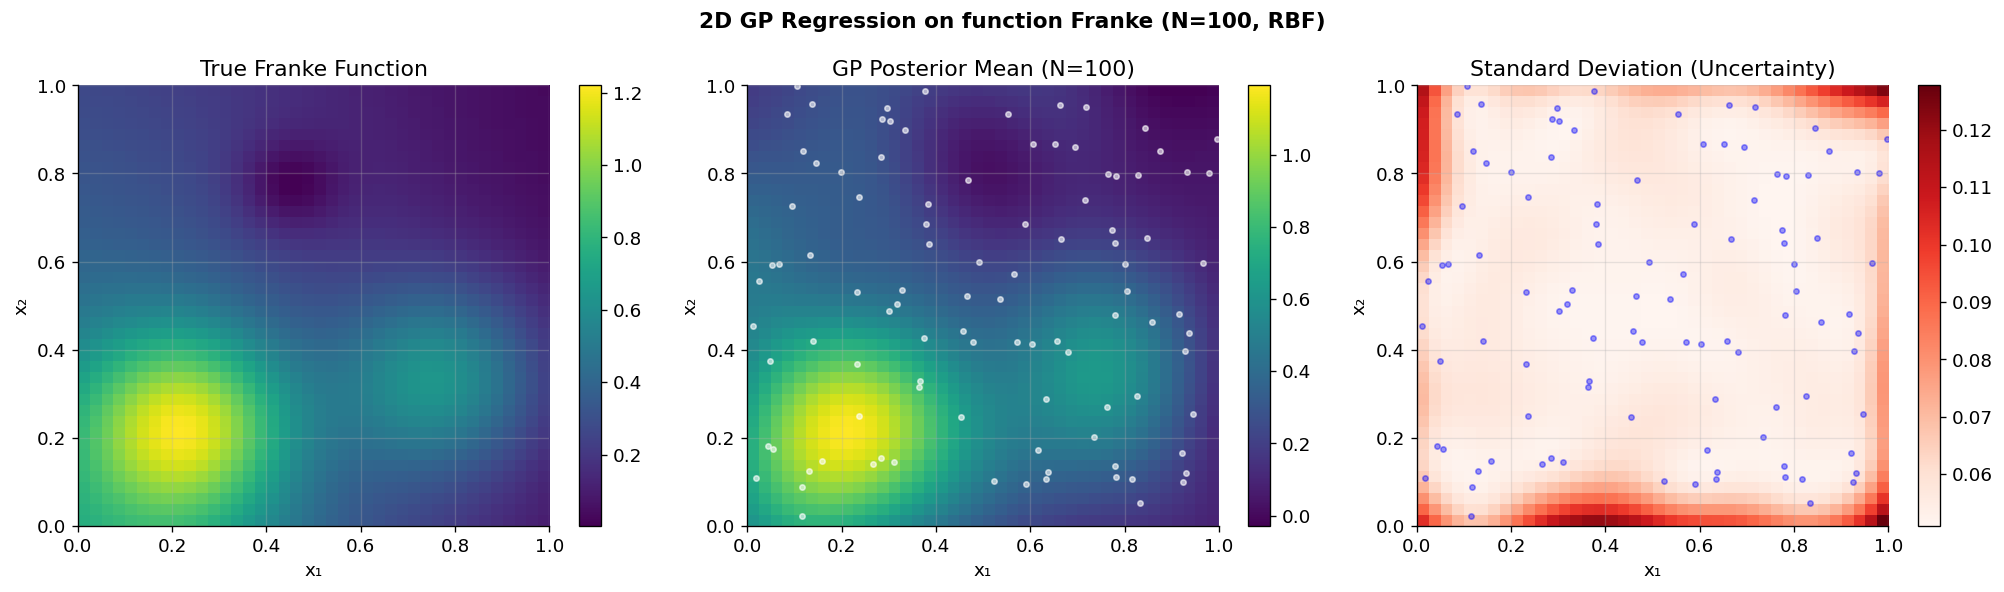

2D GP RMSE: 0.0369


In [68]:
def franke(X, Y):
    return (
        0.75 * np.exp(-((9*X-2)**2 + (9*Y-2)**2) / 4)
        + 0.75 * np.exp(-((9*X+1)**2) / 49 - (9*Y+1) / 10)
        + 0.5  * np.exp(-((9*X-7)**2 + (9*Y-3)**2) / 4)
        - 0.2  * np.exp(-(9*X-4)**2 - (9*Y-7)**2)
    )

N2D = 100
X2D_obs = rng.uniform(0, 1, (N2D, 2))
y2D_obs = franke(X2D_obs[:, 0], X2D_obs[:, 1]) + rng.normal(0, 0.05, N2D)

g = np.linspace(0, 1, 40)
Gx, Gy = np.meshgrid(g, g)
X2D_star = np.column_stack([Gx.ravel(), Gy.ravel()])
y2D_true = franke(Gx, Gy)

kernel_2d = C(1.0) * RBF(length_scale=[0.3, 0.3]) + WhiteKernel(0.05**2)
gpr_2d = GaussianProcessRegressor(kernel=kernel_2d, n_restarts_optimizer=3,
                                   random_state=SEED)
gpr_2d.fit(X2D_obs, y2D_obs)
y2D_pred, y2D_std = gpr_2d.predict(X2D_star, return_std=True)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

def imshow_args(data):
    return dict(origin='lower', extent=[0,1,0,1], aspect='auto',
                vmin=data.min(), vmax=data.max(), cmap='viridis')

im0 = axes[0].imshow(y2D_true, **imshow_args(y2D_true))
axes[0].set_title('True Franke Function'); fig.colorbar(im0, ax=axes[0])

pred_grid = y2D_pred.reshape(40, 40)
im1 = axes[1].imshow(pred_grid, **imshow_args(pred_grid))
axes[1].scatter(X2D_obs[:,0], X2D_obs[:,1], s=10, c='white', alpha=0.6)
axes[1].set_title('GP Posterior Mean (N=100)'); fig.colorbar(im1, ax=axes[1])

std_grid = y2D_std.reshape(40, 40)
im2 = axes[2].imshow(std_grid, origin='lower', extent=[0,1,0,1],
                     aspect='auto', cmap='Reds')
axes[2].scatter(X2D_obs[:,0], X2D_obs[:,1], s=10, c='blue', alpha=0.4)
axes[2].set_title('Standard Deviation (Uncertainty)')
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

fig.suptitle('2D GP Regression on function Franke (N=100, RBF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

rmse_2d = np.sqrt(np.mean((y2D_pred - franke(X2D_star[:,0], X2D_star[:,1]))**2))
print(f'2D GP RMSE: {rmse_2d:.4f}')

## 3.2.3 Mauna Loa CO₂ 

In [ ]:
import pandas as pd
import numpy as np

try:
    from sklearn.datasets import fetch_openml
    # dodano parser='auto', żeby uniknąć żółtych ostrzeżeń w nowszych wersjach biblioteki
    co2 = fetch_openml(data_id=41187, as_frame=True, parser='auto')
    co2_data = co2.frame
    
    # Preprocessing
    co2_data['date'] = pd.to_datetime(
        co2_data[['year', 'month', 'day']]
    )
    
    # Agregacja do miesięcy
    co2_data['decimal_date'] = co2_data['year'] + (co2_data['month'] - 0.5) / 12
    co2_df = (
        co2_data.groupby(co2_data['date'].dt.to_period('M'))
                .agg(decimal_date=('decimal_date', 'mean'),
                     interpolated=('co2', 'mean'))
                .reset_index(drop=True)
    )
    co2_df = co2_df.dropna()


except Exception as e:
    print(f'Downloading failed, using synthetic data.')
    t = np.linspace(1958, 2024, 800)
    co2_df = pd.DataFrame({
        'decimal_date': t,
        'interpolated': 315 + 1.5 * (t - 1958) + 3.0 * np.sin(2 * np.pi * t) + rng.normal(0, 0.5, len(t)),
    })

# --- POPRAWIONY PODZIAŁ DANYCH ---
ROK_PODZIALU = 1990

# Train / test split (dane do 1990 treningowe, wszystko po 1990 to testowe)
train_mask = co2_df['decimal_date'] < ROK_PODZIALU
test_mask  = co2_df['decimal_date'] >= ROK_PODZIALU

X_co2_train = co2_df.loc[train_mask, 'decimal_date'].values.reshape(-1, 1)
y_co2_train = co2_df.loc[train_mask, 'interpolated'].values

X_co2_test  = co2_df.loc[test_mask,  'decimal_date'].values.reshape(-1, 1)
y_co2_test  = co2_df.loc[test_mask,  'interpolated'].values

# Siatka predykcji 1958–2035 (dla pięknego rysowania wykresu w przyszłość)
X_co2_star = np.linspace(1958, 2035, 1020).reshape(-1, 1)

print(f'Train: {len(X_co2_train)} pkt  |  Test: {len(X_co2_test)} pkt')

Trening: 377 pkt  |  Test: 144 pkt
Predykcja na siatce 1958–2035: 1020 pkt


### Kernel 1: Composite (trend + seasonality + noise)

In [70]:
# Delikatnie luzujemy granice dla szumu (pozwalamy mu na więcej pokory)
k_trend    = C(50.0) * RBF(length_scale=200.0)
k_seasonal = (C(2.0)
               * ExpSineSquared(length_scale=1.0, periodicity=1.0,
                                periodicity_bounds=(0.99, 1.01))
               * RBF(length_scale=5.0))
k_medium   = C(0.5) * RationalQuadratic(alpha=1.0, length_scale=1.0)
# Dodajemy elastyczne granice dla szumu
k_noise    = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1.5))

kernel_composite = k_trend + k_seasonal + k_medium + k_noise

gpr_composite = GaussianProcessRegressor(
    kernel=kernel_composite,
    n_restarts_optimizer=25,  
    normalize_y=True,
    random_state=SEED,
)


gpr_composite.fit(X_co2_train, y_co2_train)
y_comp_pred, y_comp_std = gpr_composite.predict(X_co2_star, return_std=True)

print(gpr_composite.kernel_)

4.55**2 * RBF(length_scale=49.8) + 0.402**2 * ExpSineSquared(length_scale=2.1, periodicity=1) * RBF(length_scale=190) + 0.0899**2 * RationalQuadratic(alpha=0.0616, length_scale=1.9) + WhiteKernel(noise_level=0.001)


### Kernel 2: RBF + WhiteKernel


In [71]:
kernel_simple = C(50.0) * RBF(length_scale=10.0) + WhiteKernel(noise_level=0.5)

gpr_simple = GaussianProcessRegressor(
    kernel=kernel_simple,
    n_restarts_optimizer=3,
    normalize_y=True,
    random_state=SEED,
)
gpr_simple.fit(X_co2_train, y_co2_train)
y_simple_pred, y_simple_std = gpr_simple.predict(X_co2_star, return_std=True)

print('Simple Kernel:')
print(gpr_simple.kernel_)

Simple Kernel:
3.85**2 * RBF(length_scale=45.6) + WhiteKernel(noise_level=0.0316)


### Both kernels, prediction to 2050

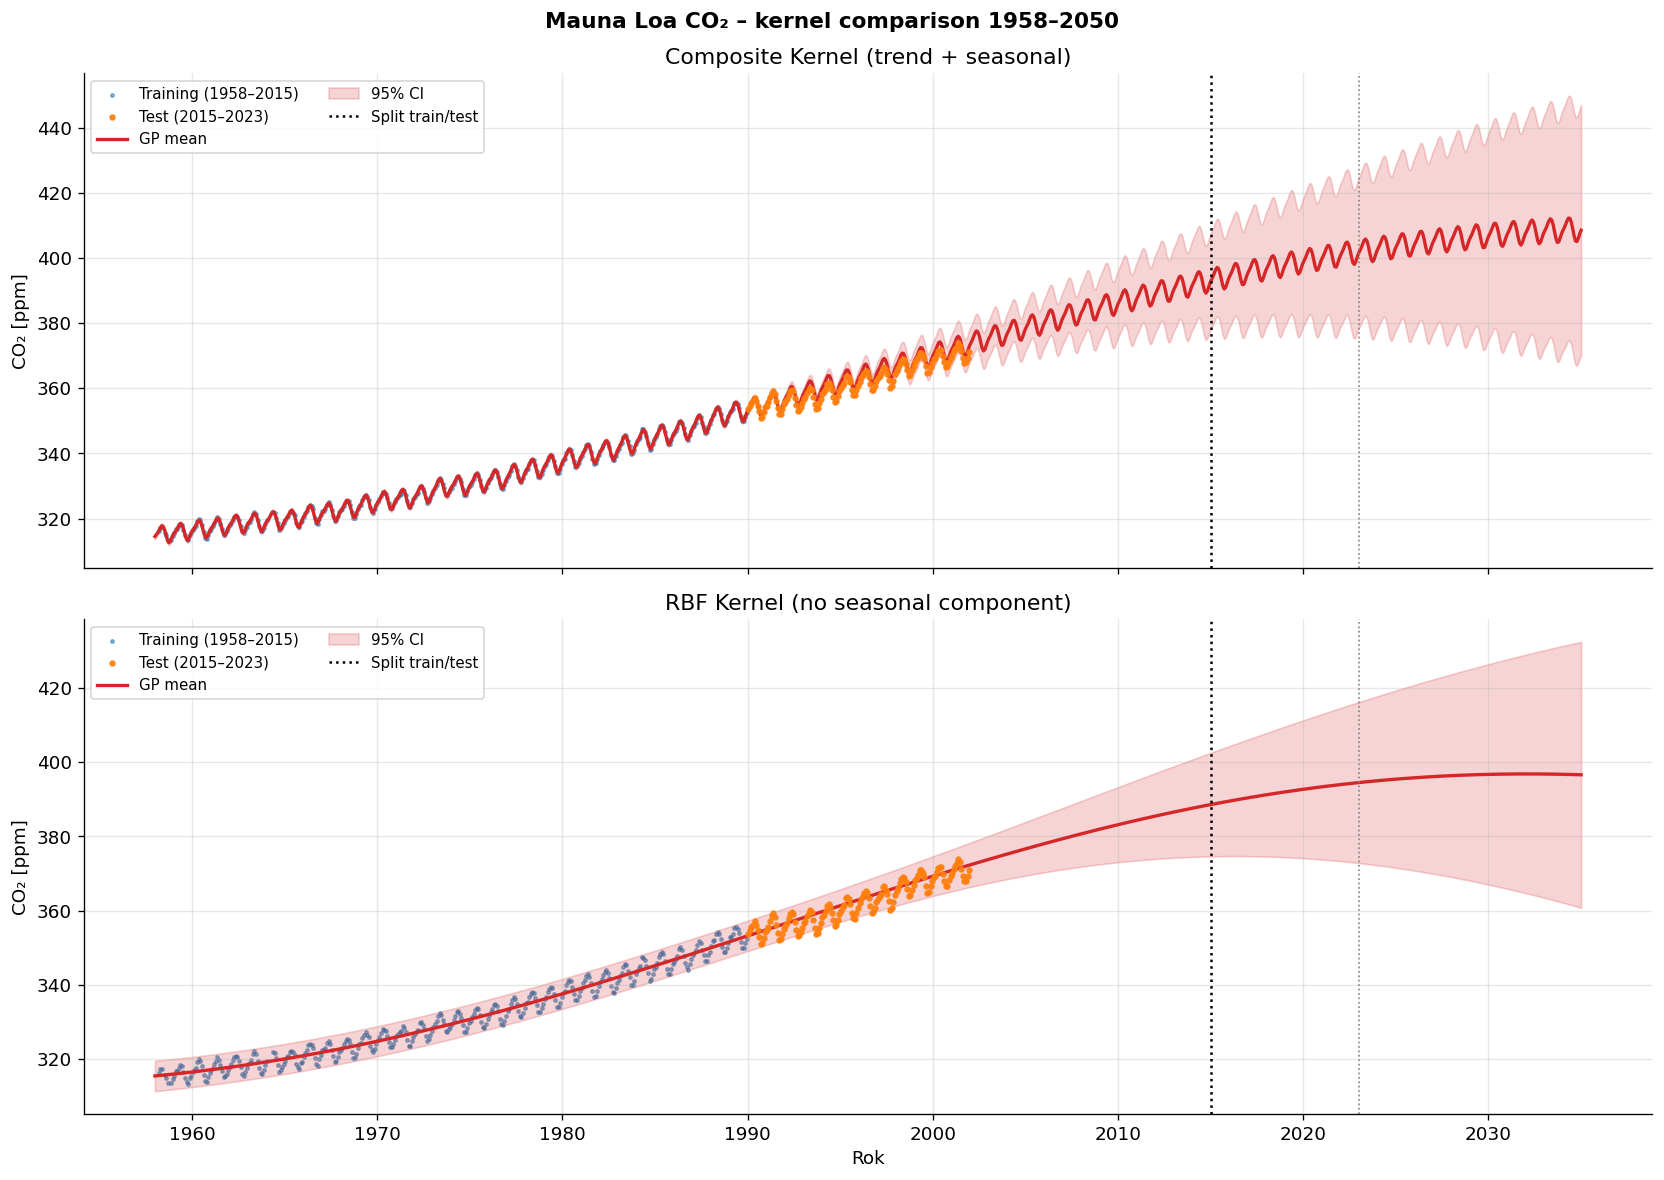

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, (gpr, y_pred, y_std, title) in zip(
    axes,
    [
        (gpr_composite, y_comp_pred, y_comp_std, 'Composite Kernel (trend + seasonal)'),
        (gpr_simple,    y_simple_pred, y_simple_std, 'RBF Kernel (no seasonal component)'),
    ]
):
    xp = X_co2_star.flatten()
    ax.scatter(X_co2_train.flatten(), y_co2_train,
               s=4, alpha=0.5, color='C0', label='Training (1958–2015)')
    ax.scatter(X_co2_test.flatten(),  y_co2_test,
               s=8, color='C1', alpha=0.9, zorder=5, label='Test (2015–2023)')
    ax.plot(xp, y_pred, 'C3', lw=2, label='GP mean')
    ax.fill_between(xp, y_pred - 2*y_std, y_pred + 2*y_std,
                    color='C3', alpha=0.2, label='95% CI')
    ax.axvline(2015, color='k', ls=':', lw=1.5, label='Split train/test')
    ax.axvline(2023, color='grey', ls=':', lw=1.0)
    ax.set(ylabel='CO₂ [ppm]', title=title)
    ax.legend(fontsize=9, ncol=2)

axes[1].set_xlabel('Year')
plt.suptitle('Mauna Loa CO₂ – kernel comparison 1958–2050',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Analysing RMSE

In [73]:
for label, gpr in [('Composite', gpr_composite), ('Simple RBF', gpr_simple)]:
    # Zgadywanie z wymuszonym spłaszczeniem (flatten), żeby uniknąć błędu wymiarów
    y_pred_test, y_std_test = gpr.predict(X_co2_test, return_std=True)
    y_pred_test = y_pred_test.flatten()
    y_std_test = y_std_test.flatten()
    
    # Obliczenie błędu
    rmse = np.sqrt(np.mean((y_pred_test - y_co2_test)**2))

    # Procent punktów testowych w paśmie ±2σ (oczekiwane ≈ 95%)
    inside_95 = np.mean(
        (y_co2_test >= y_pred_test - 2 * y_std_test) &
        (y_co2_test <= y_pred_test + 2 * y_std_test)
    ) * 100

    # Procent punktów testowych w paśmie ±1σ (oczekiwane ≈ 68%)
    inside_68 = np.mean(
        (y_co2_test >= y_pred_test - y_std_test) &
        (y_co2_test <= y_pred_test + y_std_test)
    ) * 100

    print(f'Kernel: {label}')
    print(f'  Test RMSE              : {rmse:.3f} ppm')
    print(f'  Coverage ±2σ (expected 95%): {inside_95:.1f}%')
    print(f'  Coverage ±1σ (expected 68%): {inside_68:.1f}%')
    print('-' * 40)

Kernel: Composite
  Test RMSE              : 1.817 ppm
  Coverage ±2σ (expected 95%): 83.3%
  Coverage ±1σ (expected 68%): 38.9%
----------------------------------------
Kernel: Simple RBF
  Test RMSE              : 2.459 ppm
  Coverage ±2σ (expected 95%): 92.4%
  Coverage ±1σ (expected 68%): 66.0%
----------------------------------------


## 3.2.4 Kernels on 1D data

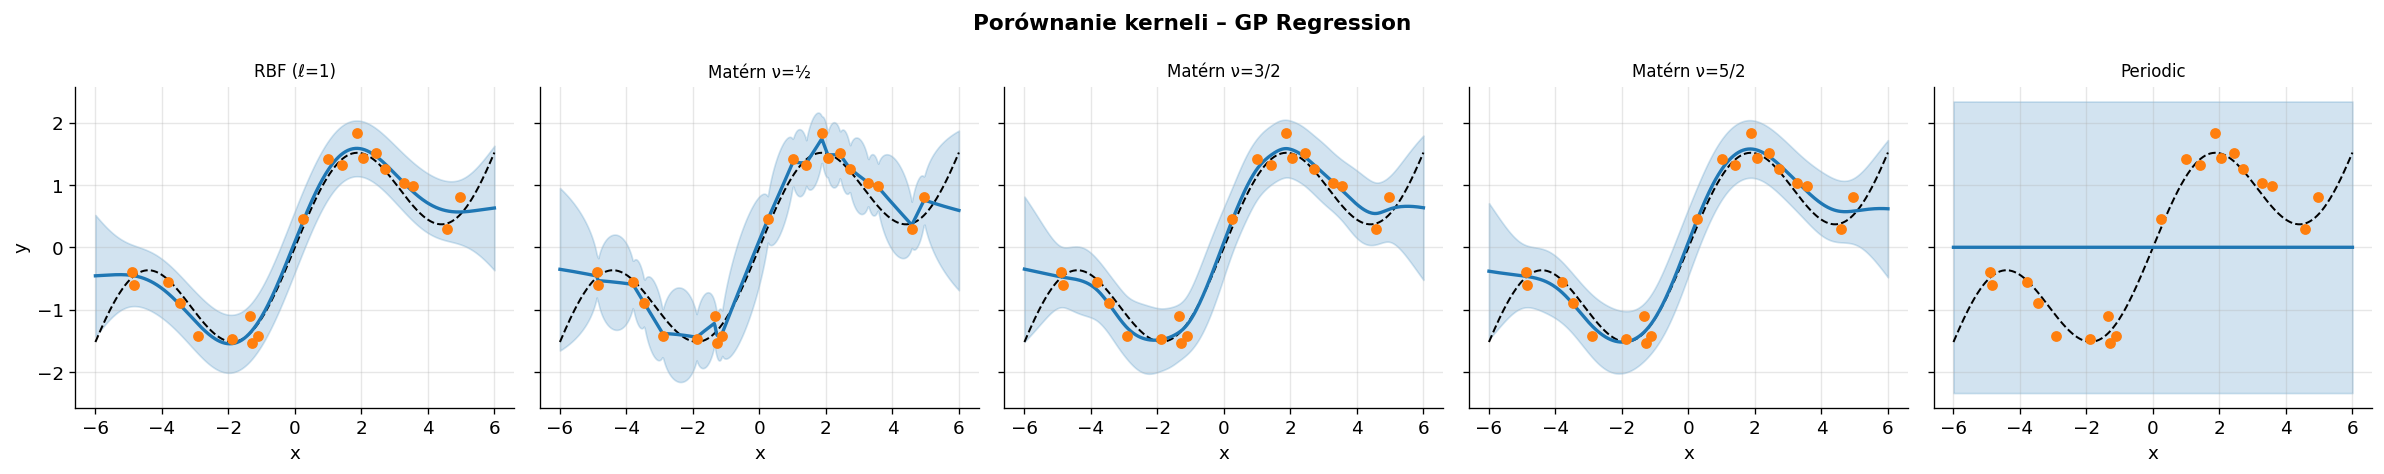

In [ ]:
def target(x): return np.sin(x) + 0.3 * x

N_kcomp  = 20
x_kc     = rng.uniform(-5, 5, N_kcomp)
y_kc     = target(x_kc) + rng.normal(0, 0.2, N_kcomp)
x_star_kc = np.linspace(-6, 6, 500).reshape(-1, 1)

kernel_zoo = {
    'RBF (ℓ=1)':     RBF(1.0),
    'Matérn ν=½':    Matern(length_scale=1.0, nu=0.5),
    'Matérn ν=3/2':  Matern(length_scale=1.0, nu=1.5),
    'Matérn ν=5/2':  Matern(length_scale=1.0, nu=2.5),
    'Periodic':      ExpSineSquared(length_scale=1.0, periodicity=3.0),
}

fig, axes = plt.subplots(1, len(kernel_zoo), figsize=(20, 4), sharey=True)

for ax, (kname, k) in zip(axes, kernel_zoo.items()):
    gpr = GaussianProcessRegressor(
        kernel=C(1.0) * k + WhiteKernel(0.04),
        n_restarts_optimizer=3,
        random_state=SEED,
    )
    gpr.fit(x_kc.reshape(-1, 1), y_kc)
    mu, std = gpr.predict(x_star_kc, return_std=True)
    xp = x_star_kc.flatten()

    ax.plot(xp, target(xp), 'k--', lw=1.2, label='Prawdziwa')
    ax.scatter(x_kc, y_kc, s=30, color='C1', zorder=5)
    ax.plot(xp, mu, 'C0', lw=2)
    ax.fill_between(xp, mu - 2*std, mu + 2*std, color='C0', alpha=0.2)
    ax.set_title(kname, fontsize=10)
    ax.set_xlabel('x')

axes[0].set_ylabel('y')
fig.suptitle('Kernel Comparison – GP Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.2.5 Time complexity of GP

Exact GP requires a Cholesky decomposition of the $N \times N$ kernel matrix:

$$\text{Time: } \mathcal{O}(N^3) \qquad \text{Memory: } \mathcal{O}(N^2)$$

For $N \approx 10\,000$ this becomes prohibitive on standard hardware.

N=   50  czas=0.003s
N=  100  czas=0.004s
N=  200  czas=0.007s
N=  400  czas=0.020s
N=  800  czas=0.084s
N= 1500  czas=0.213s
N= 3000  czas=1.280s


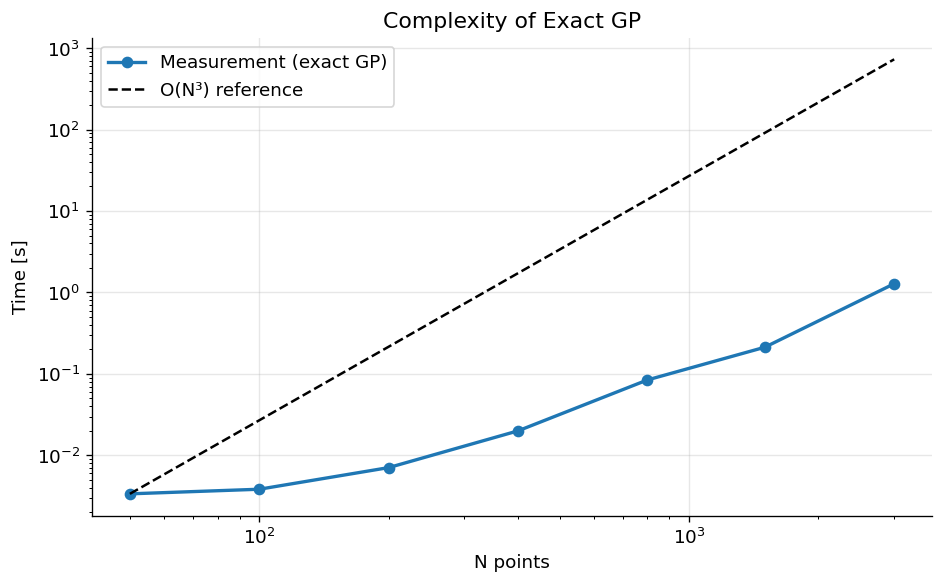

In [75]:
import time

sizes = [50, 100, 200, 400, 800, 1500, 3000]
times_exact = []

kernel_bench = RBF(1.0) + WhiteKernel(0.01)

for n in sizes:
    x_bench = rng.uniform(-5, 5, n)
    y_bench = np.sin(x_bench) + rng.normal(0, 0.1, n)
    gpr_bench = GaussianProcessRegressor(kernel=kernel_bench, optimizer=None)
    t0 = time.perf_counter()
    gpr_bench.fit(x_bench.reshape(-1, 1), y_bench)
    times_exact.append(time.perf_counter() - t0)
    print(f'N={n:5d}  czas={times_exact[-1]:.3f}s')

sizes_arr  = np.array(sizes, dtype=float)
times_arr  = np.array(times_exact)
ref_cubic  = times_arr[0] * (sizes_arr / sizes_arr[0])**3

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(sizes_arr, times_arr, 'o-C0', lw=2, label='Measurement (exact GP)')
ax.loglog(sizes_arr, ref_cubic, 'k--', lw=1.5, label='O(N³) reference')
ax.set(xlabel='N points', ylabel='Time [s]',
       title='Complexity of Exact GP')
ax.legend()
plt.tight_layout()
plt.show()

### Discussion – Complexity and Scaling Methods

**Exact GP** ($\mathcal{O}(N^3)$ time, $\mathcal{O}(N^2)$ memory) is practical up to $N \approx 5000$–$10000$ on typical hardware.

**Methods for large datasets:**

1. **Sparse GP / Inducing Points** (Snelson & Ghahramani 2006; Titsias 2009)  
   Select $m \ll N$ inducing points → $\mathcal{O}(Nm^2)$ training, $\mathcal{O}(m^2)$ prediction.

2. **Structured Kernel Interpolation (SKI/KISS-GP)** (Wilson & Nickisch 2015)  
   Exploits grid structure → $\mathcal{O}(N + m \log m)$ via FFT.

3. **Stochastic Variational GP (SVGP)** (Hensman et al. 2013)  
   Mini-batch SGD + inducing points → scales to millions of data points (default option in GPyTorch for large datasets).

4. **Random Fourier Features** (Rahimi & Recht 2007)  
   Kernel approximation via $D$ random features → $\mathcal{O}(ND)$ training, $\mathcal{O}(D)$ prediction.

5. **Deep Kernel Learning** (Wilson et al. 2016)  
   Neural network as feature extractor + GP kernel → combines network flexibility with GP uncertainty quantification.

---

## Summary

### Problem 3.1 – Bayesian Linear Regression

| Aspect | MLE (OLS) | Bayesian (NUTS) |
|--------|-----------|------------------|
| Parameter estimation | Point estimate | Full posterior distribution |
| Uncertainty | None (or bootstrap) | Credible intervals (HDI) |
| Prediction | Single value | Posterior predictive distribution |
| Small data | Overconfidence | Regularization via prior |

**Conclusion:** With $N=60$ both methods yield very similar estimates. The Bayesian approach additionally provides 94% HDI for each parameter, a posterior mean curve, and intervals for both E[y|x] and new $Y_i$.

### Problem 3.2 – Gaussian Process Regression

| Kernel | Smoothness | Application |
|--------|----------|---------------|
| RBF | $C^\infty$ | Very smooth physical processes |
| Matérn ν=3/2 | $C^1$ | Most practical tasks |
| Matérn ν=5/2 | $C^2$ | Slightly smoother data |
| Periodic | Periodic | Seasonal signals |
| Composite | Complex | Real-world data (CO₂) |

**Conclusion:** The composite kernel (trend + seasonal + noise) decisively outperforms a simple RBF on CO₂ data — both in terms of RMSE and test-point coverage within the uncertainty band. Exact GP scales as $\mathcal{O}(N^3)$ — for large datasets, approximate methods are necessary.

In [76]:
# Core numerical and data handling libraries
import numpy as np
import pandas as pd
import scipy.stats as stats

# Standard library
import json
import urllib.request
from io import BytesIO
import warnings

# Plotting
import matplotlib.pyplot as plt

# Time series tools
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



# Problem 3

## Data loading
For our analysis we choose the Apple stock prices. The period covered by data is 20.04.2021 - 17.04.2026.

In [77]:
path = 'Apple_stock_price.csv'
Stock_prices = pd.read_csv(path, index_col=0, parse_dates=True)
Stock_prices.head()
Stock_prices["Close/Last"] = Stock_prices["Close/Last"].str.replace("$", "", regex=False).astype(float)

## Visualization of data

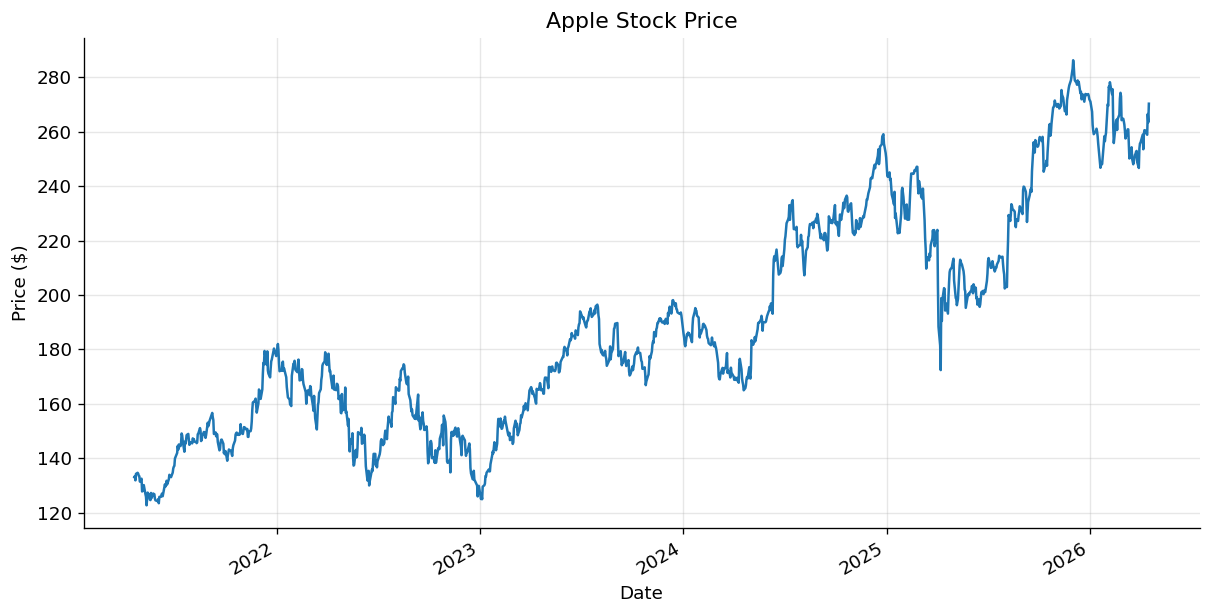

In [78]:
plt.figure(figsize=(12, 6))
Stock_prices['Close/Last'].plot()
plt.title('Apple Stock Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

Train set length: 1004
Test set length: 251


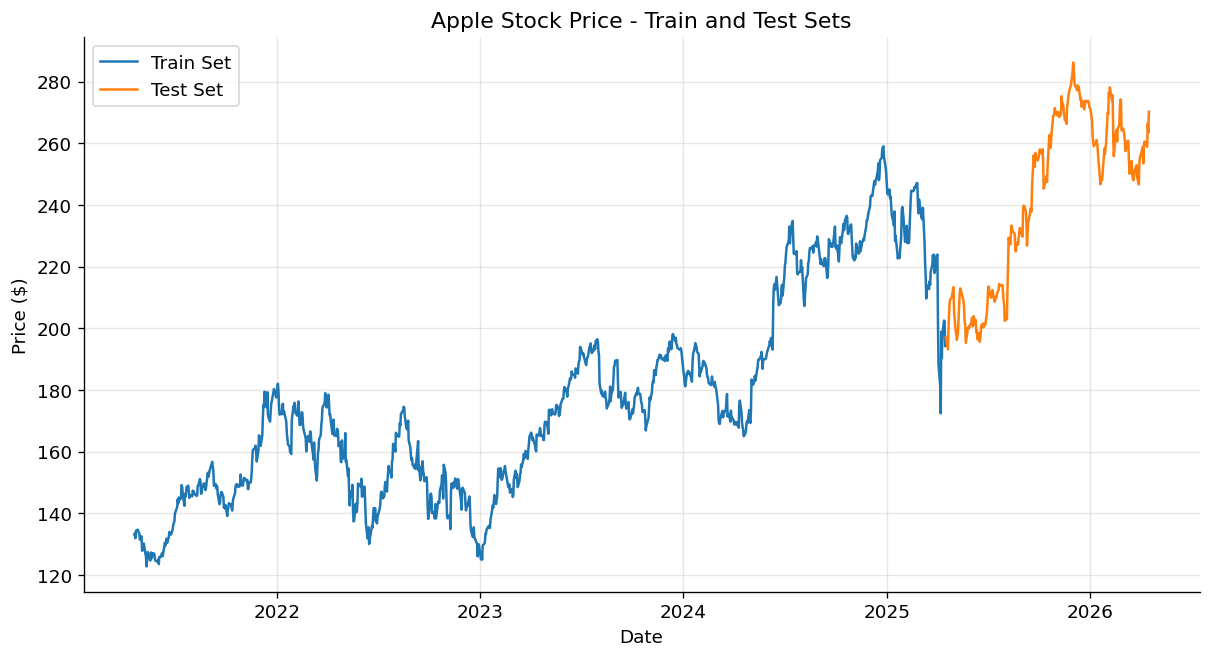

In [79]:
#train test split
test_ratio = 0.2
Test_set = Stock_prices.iloc[:int(len(Stock_prices) * test_ratio)]
Train_set = Stock_prices.iloc[int(len(Stock_prices) * test_ratio):]
print(f"Train set length: {len(Train_set)}")
print(f"Test set length: {len(Test_set)}")

#plotting train and test sets
plt.figure(figsize=(12, 6))
plt.plot(Train_set.index, Train_set['Close/Last'], label='Train Set')
plt.plot(Test_set.index, Test_set['Close/Last'], label='Test Set')
plt.title('Apple Stock Price - Train and Test Sets')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)

Train and test set visualization. We can easily see a presence of micro trends and regimes changes in our data. That is the reason why we will proceed with returns transformation.

## Returns of Apple stock prices

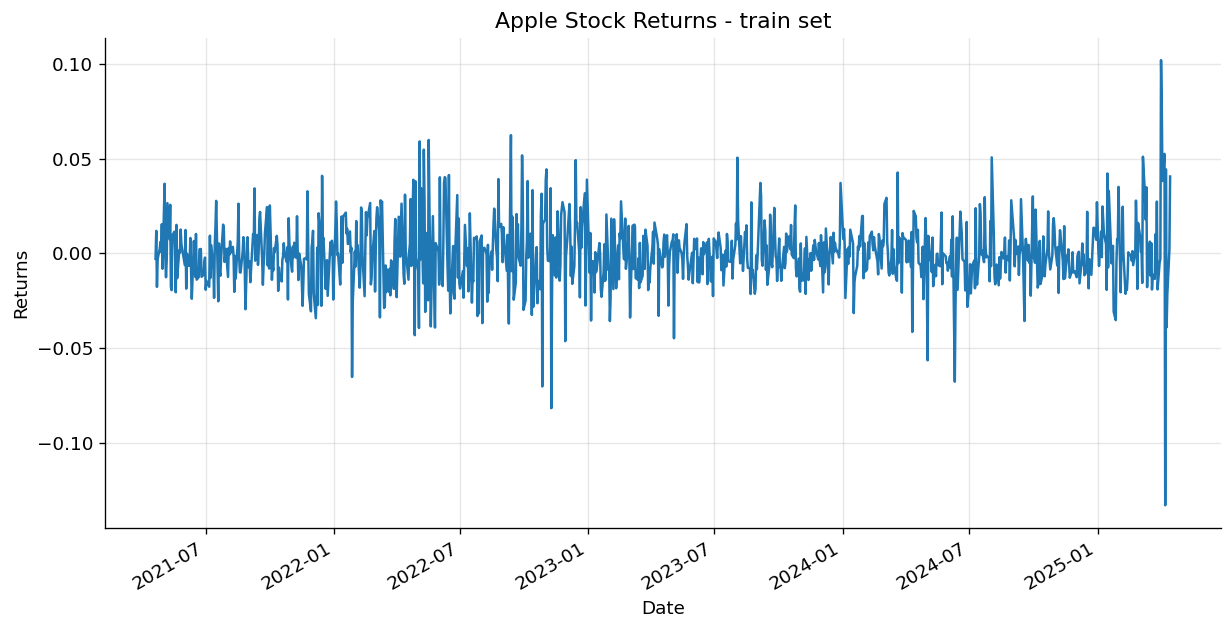

In [80]:
Train_returns = Train_set['Close/Last'].pct_change().dropna()
plt.figure(figsize=(12, 6))
Train_returns.plot()
plt.title('Apple Stock Returns - train set')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.grid(True)
plt.show()

In [81]:
#ad fuller test
result = adfuller(Train_returns)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -31.386028
p-value: 0.000000


Both ad fuller test and plot showed us that returns are stationary. Therefore we will further consider d parameter equals to 1 in **ARIMA(p,d,q)** model.

## Fitting **ARIMA** model

In [82]:
#ARIMA model
best_aic = np.inf
for p in range(0,5):
    for q in range(0,5):
        try:
            mdl = ARIMA(Train_set['Close/Last'], order=(p, 1, q))
            model_fit = mdl.fit()
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, 1, q)
        except:
            continue
        
print(f"Best ARIMA order: {best_order} with AIC: {best_aic}")
mdl = ARIMA(Train_set['Close/Last'], order=best_order)
model_fit = mdl.fit()
print(model_fit.summary())

Best ARIMA order: (4, 1, 1) with AIC: 5124.691974209612
                               SARIMAX Results                                
Dep. Variable:             Close/Last   No. Observations:                 1004
Model:                 ARIMA(4, 1, 1)   Log Likelihood               -2556.346
Date:                Fri, 24 Apr 2026   AIC                           5124.692
Time:                        12:45:02   BIC                           5154.156
Sample:                             0   HQIC                          5135.889
                               - 1004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9126      0.033    -27.920      0.000      -0.977      -0.848
ar.L2          0.0297      0.033      0.894      0.371      -0.035       0.

Using AIC criterion we found that the most suitable model for our data is **ARIMA(4,1,1)**. The value of AIC in this case is around 5125. The exact parameters of the considered model are shown in the table above.

## Autocorrelation and partial autocorrelation in training dataset

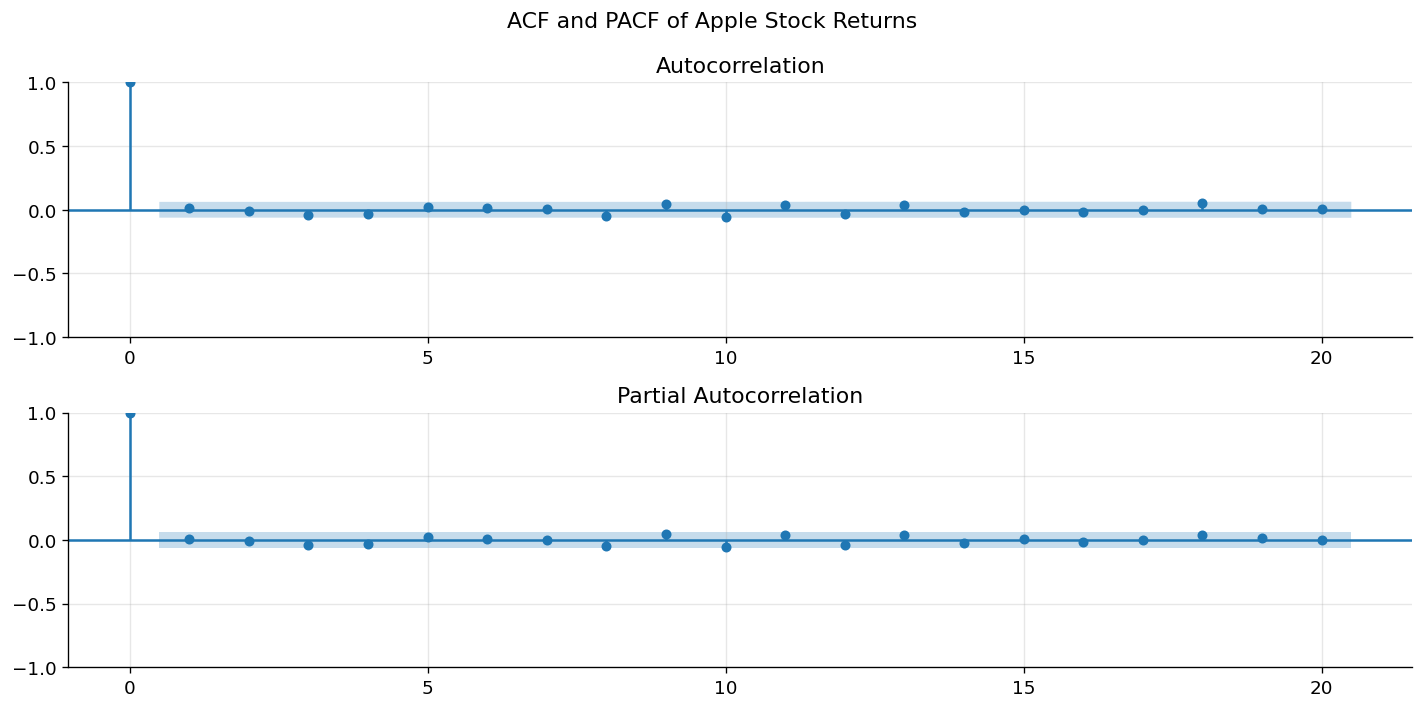

In [83]:
#pacf and acf plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12, 6))
plt.suptitle('ACF and PACF of Apple Stock Returns')
plt.subplot(2, 1, 1)
plot_acf(Train_returns, ax=plt.gca(), lags=20)
plt.subplot(2, 1, 2)
plot_pacf(Train_returns, ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

Autocorrelation and partial autocorrelation plots don't suggest to choose model fitted earlier. However we cannot consider model **ARIMA(0,1,0)** because it would mean that our returns are just a noise. Now let's analyze the residuals of our model.

## Residuals analysis

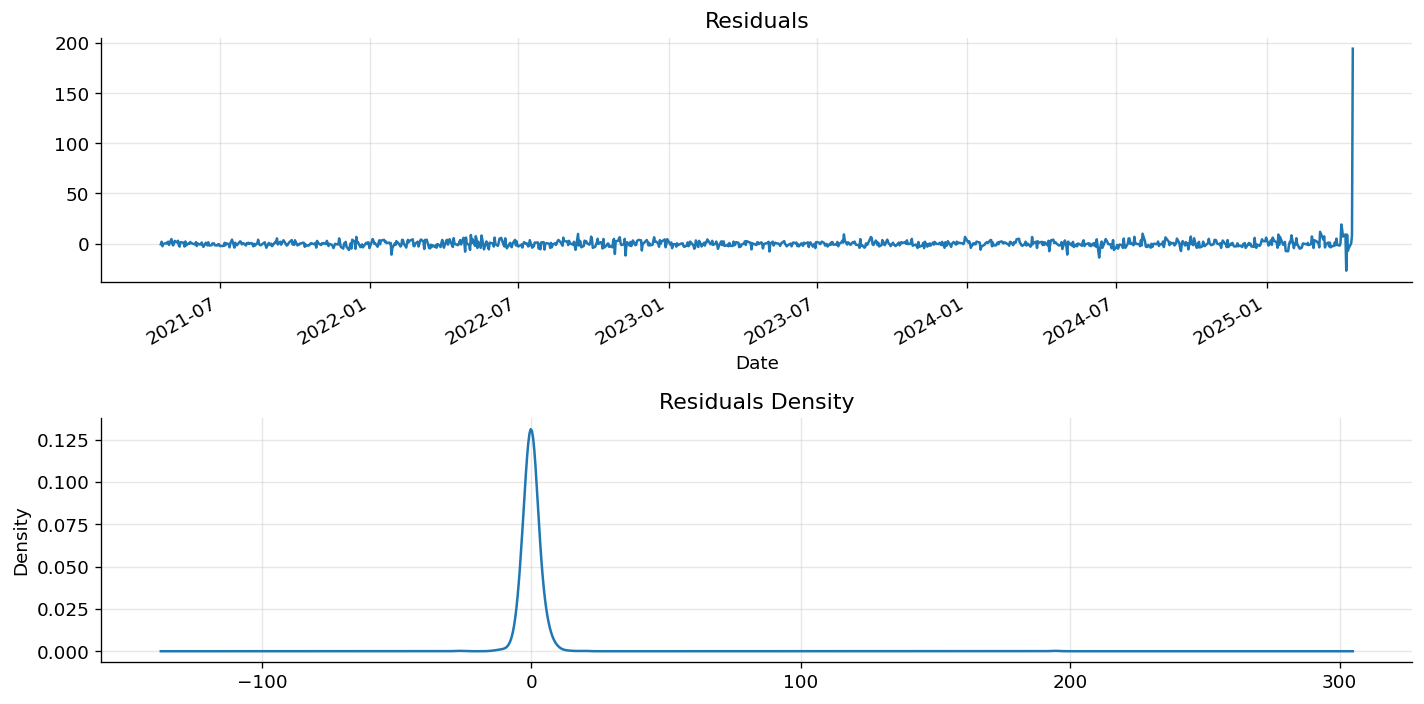

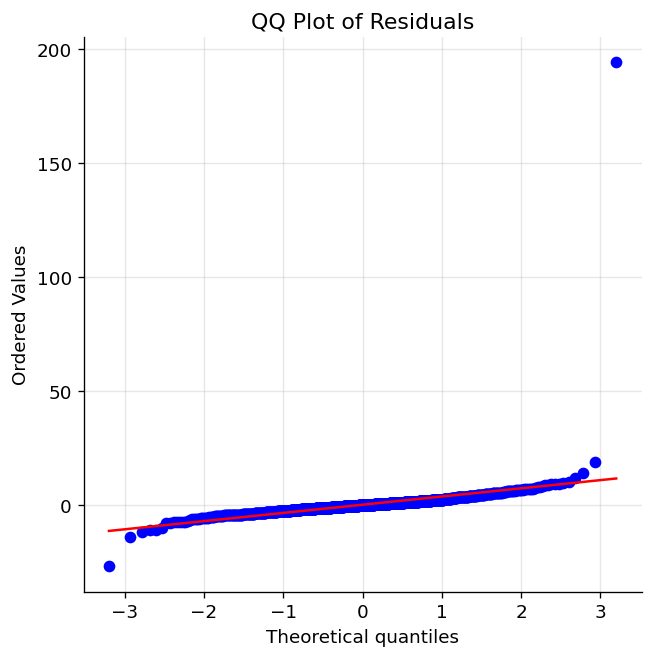

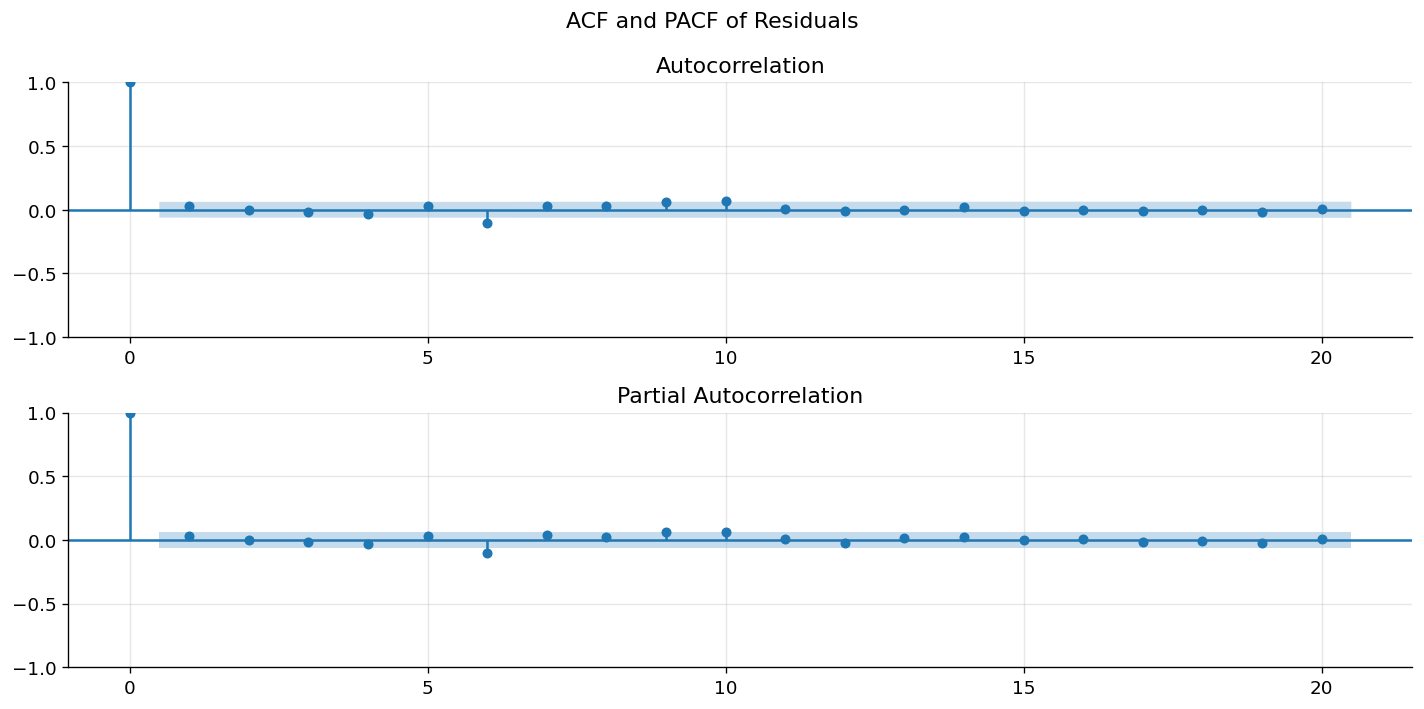

In [84]:
#residuals analysis
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
residuals.plot(title='Residuals')
plt.subplot(2, 1, 2)
residuals.plot(kind='kde', title='Residuals Density')
plt.tight_layout()
plt.show()

#qq plot of residuals
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals')
plt.grid(True)
plt.show()

#acf and pacf of residuals
plt.figure(figsize=(12, 6))
plt.suptitle('ACF and PACF of Residuals')
plt.subplot(2, 1, 1)
plot_acf(residuals, ax=plt.gca(), lags=20)
plt.subplot(2, 1, 2)
plot_pacf(residuals, ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

In [85]:
#test for normality of residuals
statistic, p_value = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test Statistic: {statistic}')
print(f'Shapiro-Wilk Test p-value: {p_value}')

Shapiro-Wilk Test Statistic: 0.2808141713224295
Shapiro-Wilk Test p-value: 3.245290993630673e-52


Residuals of our model seems to be uncorrelated, while their distribution is likely to have heavier tails than normal distribution (the hypothesis of our data to be normal is rejected by Shapiro-Wilk test at $\alpha = 0.05$). What is more there is one obvious outlier in our data, which makes distribution fitting rather a hard task. Now we will go throught validation of our model using the test dataset.

## Model validation

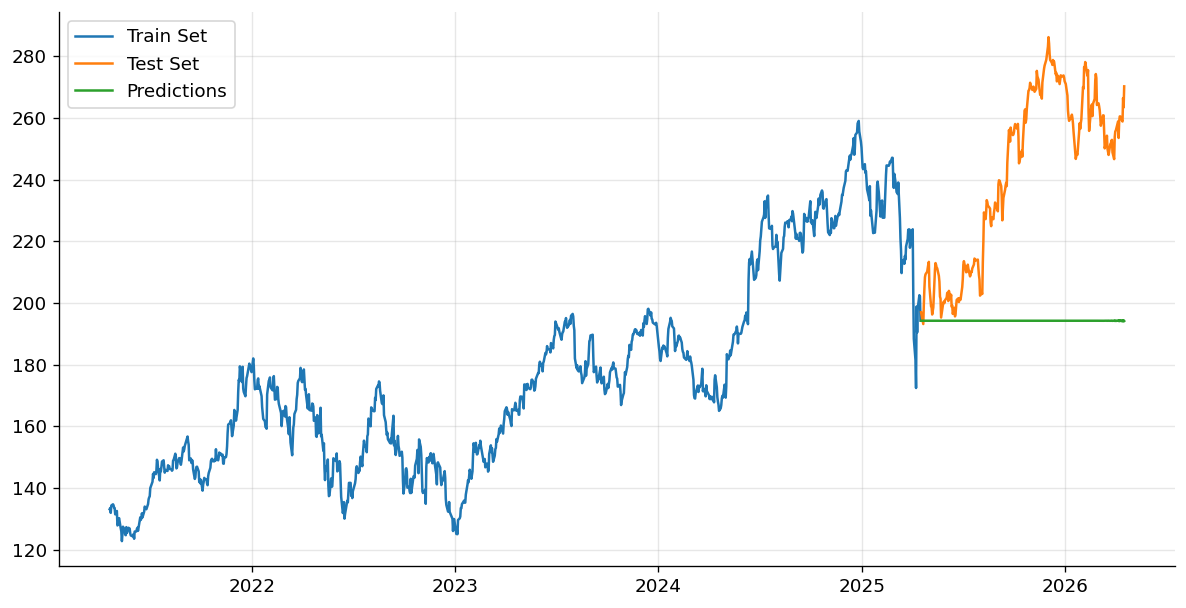

RMSE: 55.21195136007179
Mean of Test Set: 242.14414342629482


In [86]:
#model validation
predictions = model_fit.forecast(steps=len(Test_set))
plt.figure(figsize=(12, 6))
plt.plot(Train_set.index, Train_set['Close/Last'], label='Train Set')
plt.plot(Test_set.index, Test_set['Close/Last'], label='Test Set')
plt.plot(Test_set.index, predictions - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0], label='Predictions')
plt.legend()
plt.grid(True)
plt.show()

#RSME calculation
rmse = np.sqrt(np.mean((predictions.values - Test_set['Close/Last'] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0]).dropna()**2))
print(f'RMSE: {rmse}')
print(f'Mean of Test Set: {Test_set["Close/Last"].mean()}')



We can see above that simple forcast based on expected value of **ARIMA** model is not efficient in long term. The value of RSME metric is around 55, while the average value of our data is about 242. Therefore the relative error is about 23% and makes this model unuseable.

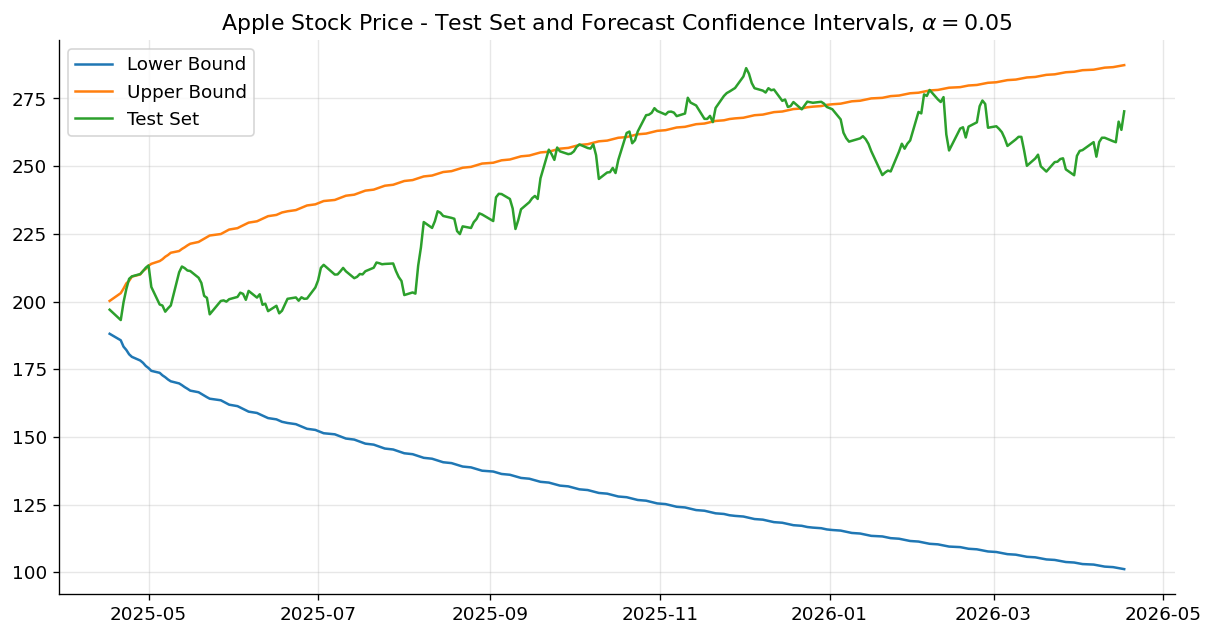

Coverage of 95% confidence intervals: 78.09%


In [87]:
#forecast quant lines
plt.figure(figsize=(12, 6))
plt.plot(Test_set.index, model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 0] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0], label='Lower Bound')
plt.plot(Test_set.index, model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 1] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0], label='Upper Bound')
plt.plot(Test_set.index, Test_set['Close/Last'], label='Test Set')
plt.title(r'Apple Stock Price - Test Set and Forecast Confidence Intervals, $\alpha=0.05$')
plt.legend()
plt.grid(True)
plt.show()

#coverage of confidence intervals
lower_bound = model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 0] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0]
upper_bound = model_fit.get_forecast(steps=len(Test_set)).conf_int(alpha=0.05).iloc[::-1, 1] - Train_set['Close/Last'][-1] + Train_set['Close/Last'][0]
coverage = np.mean((Test_set['Close/Last'] >= lower_bound.values) & (Test_set['Close/Last'] <= upper_bound.values))
print(f'Coverage of 95% confidence intervals: {coverage:.2%}')


What is more the coverage of quantiles lines obtained via **ARIMA** model differs significantly from theoretical values. For 95% confidence interval, only 78.09% of actual observations is included. It suggest that for this particular dataset we should take diffrent modeling approach.

## **ARIMA** for full dataset

As a finnal step we will train **ARIMA(4,1,1)** once again, this time utilizing whole dataset as training data. Then we will consider 30-days long forecast consisting of confidence intervals and expected value. 

In [88]:
#ARIMA for whole dataset
model_full = arima.model.ARIMA(Stock_prices['Close/Last'], order=best_order)
model_full_fit = model_full.fit()
print(model_full_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Close/Last   No. Observations:                 1255
Model:                 ARIMA(4, 1, 1)   Log Likelihood               -3235.226
Date:                Fri, 24 Apr 2026   AIC                           6482.452
Time:                        12:45:05   BIC                           6513.257
Sample:                             0   HQIC                          6494.031
                               - 1255                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8590      0.201      4.268      0.000       0.464       1.253
ar.L2         -0.0273      0.028     -0.979      0.327      -0.082       0.027
ar.L3         -0.0474      0.026     -1.835      0.0

Interestingly we can observe that not only the values of model coefficients changed compared to the old model, but also their sign changed in some cases. Now let us consider the 30-days forecast mentioned before.

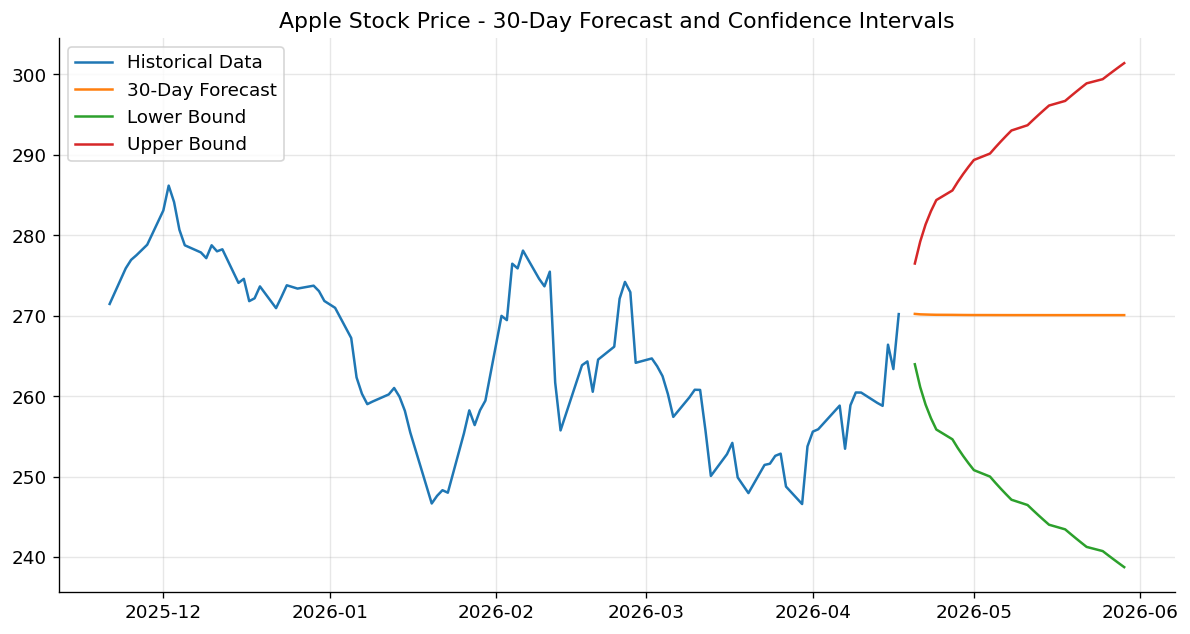

In [89]:
#30-day forecast and confidence intervals plot
forecast_30 = model_full_fit.forecast(steps=30)
plt.figure(figsize=(12, 6))
plt.plot(Stock_prices.index[:100], Stock_prices['Close/Last'][:100], label='Historical Data')
forecast_index = pd.date_range(start=Stock_prices.index[0] + pd.Timedelta(days=1), periods=30, freq='B')
plt.plot(forecast_index, forecast_30 - Stock_prices['Close/Last'].iloc[-1] + Stock_prices['Close/Last'].iloc[0], label='30-Day Forecast')      
plt.plot(forecast_index, model_full_fit.get_forecast(steps=31).conf_int(alpha=0.05).iloc[:-1, 0] - Stock_prices['Close/Last'].iloc[-1] + Stock_prices['Close/Last'].iloc[0], label='Lower Bound')
plt.plot(forecast_index, model_full_fit.get_forecast(steps=31).conf_int(alpha=0.05).iloc[:-1, 1] - Stock_prices['Close/Last'].iloc[-1] + Stock_prices['Close/Last'].iloc[0], label='Upper Bound')
plt.title('Apple Stock Price - 30-Day Forecast and Confidence Intervals')
plt.legend()
plt.grid(True)
plt.show()


Our work ends there because we do not have access to the future values of Apple stock prices (unfortunately). However based on previous analysis we should be suspicious about this forecast.

# Problem 4

## Data loading 

In this problem we will consider the prices of S&P500. The data is from 12.04.2010-21.04.2026 period. 

In [90]:
path = 'SP500_prices.csv'
SP500_prices = pd.read_csv(path, index_col=0, parse_dates=True)
SP500_prices.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-04-12,1194.94,1199.20,1194.71,1196.48,2.559494e+09
2010-04-13,1195.94,1199.04,1188.82,1197.30,3.001989e+09
2010-04-14,1198.69,1210.65,1198.69,1210.65,3.200022e+09
2010-04-15,1210.77,1213.92,1208.50,1211.67,3.330739e+09
2010-04-16,1210.17,1210.17,1186.77,1192.13,4.504706e+09


## Data visualization

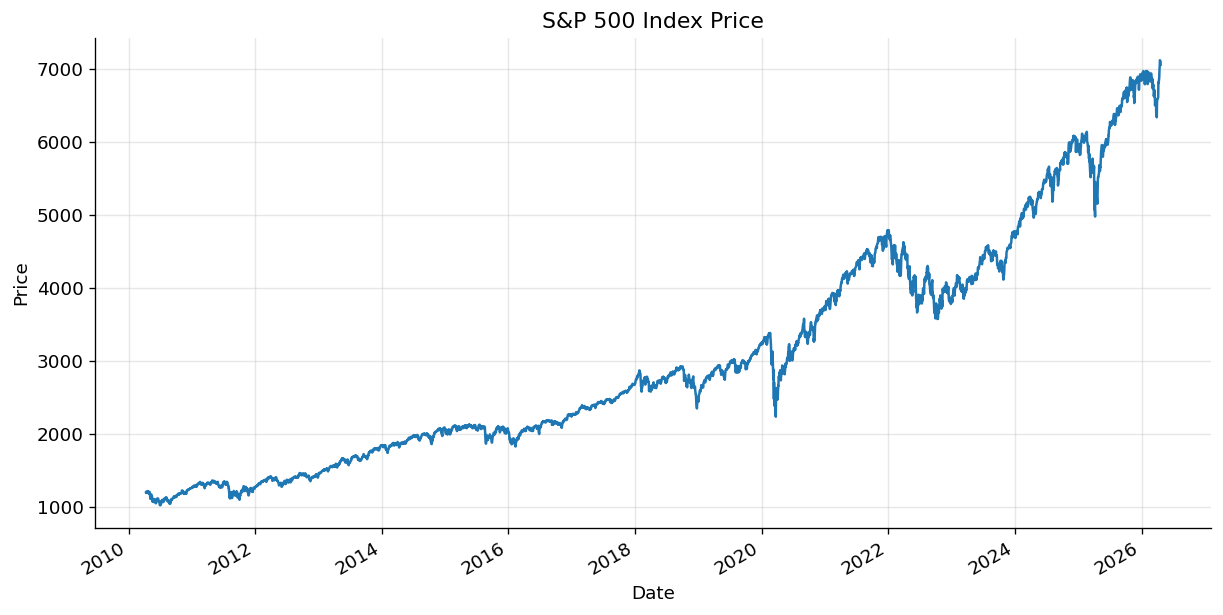

In [91]:
plt.figure(figsize=(12, 6))
SP500_prices['Close'].plot()
plt.title('S&P 500 Index Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

## Log returns

Now we will introduce the transformation of the data, which is given by the formula
$$
R_t = \log(\frac{P_t}{P_{t-1}}),
$$
where $P_t$ is the price at day $t$ and $R_t$ is log return at day $t$.

Train set length: 4011
Test set length: 20
ADF Statistic: -13.692360
p-value: 0.000000


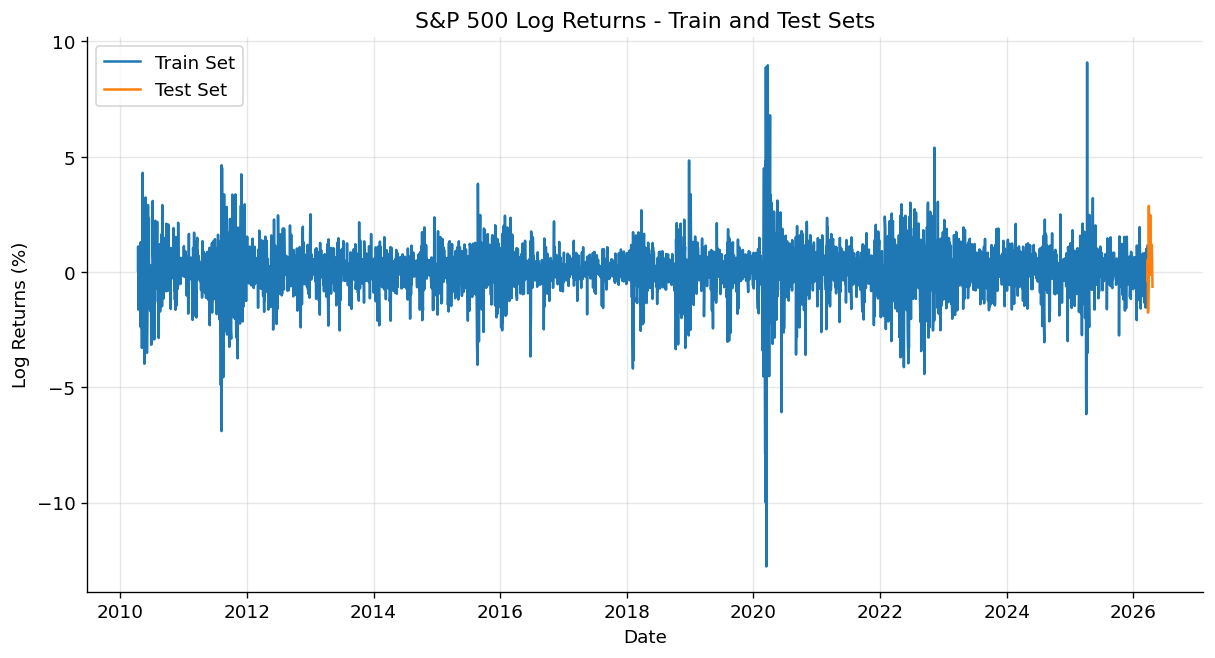

In [92]:
log_returns = np.log(SP500_prices['Close'] / SP500_prices['Close'].shift(1)).dropna()

test_set_elements = 20
Test_set = 100*log_returns.iloc[-test_set_elements:]
Train_set = 100*log_returns.iloc[:-test_set_elements]
print(f"Train set length: {len(Train_set)}")
print(f"Test set length: {len(Test_set)}")

adfuller_result = adfuller(Train_set)
print('ADF Statistic: %f' % adfuller_result[0])
print('p-value: %f' % adfuller_result[1])

plt.figure(figsize=(12, 6))
plt.plot(Train_set.index, Train_set, label='Train Set')
plt.plot(Test_set.index, Test_set, label='Test Set')
plt.title('S&P 500 Log Returns - Train and Test Sets')
plt.xlabel('Date')
plt.ylabel('Log Returns (%)')
plt.legend()
plt.grid(True)
plt.show()

The graph above shows us the change of log returns in time. We also performed the ad Fuller test, which showed us that after the transformation our data is the stationary time series ($\alpha=0.05$). We also splited the dataset into training and test set, which are visualized with diffrent colors.

## ACF and PACF of training dataset

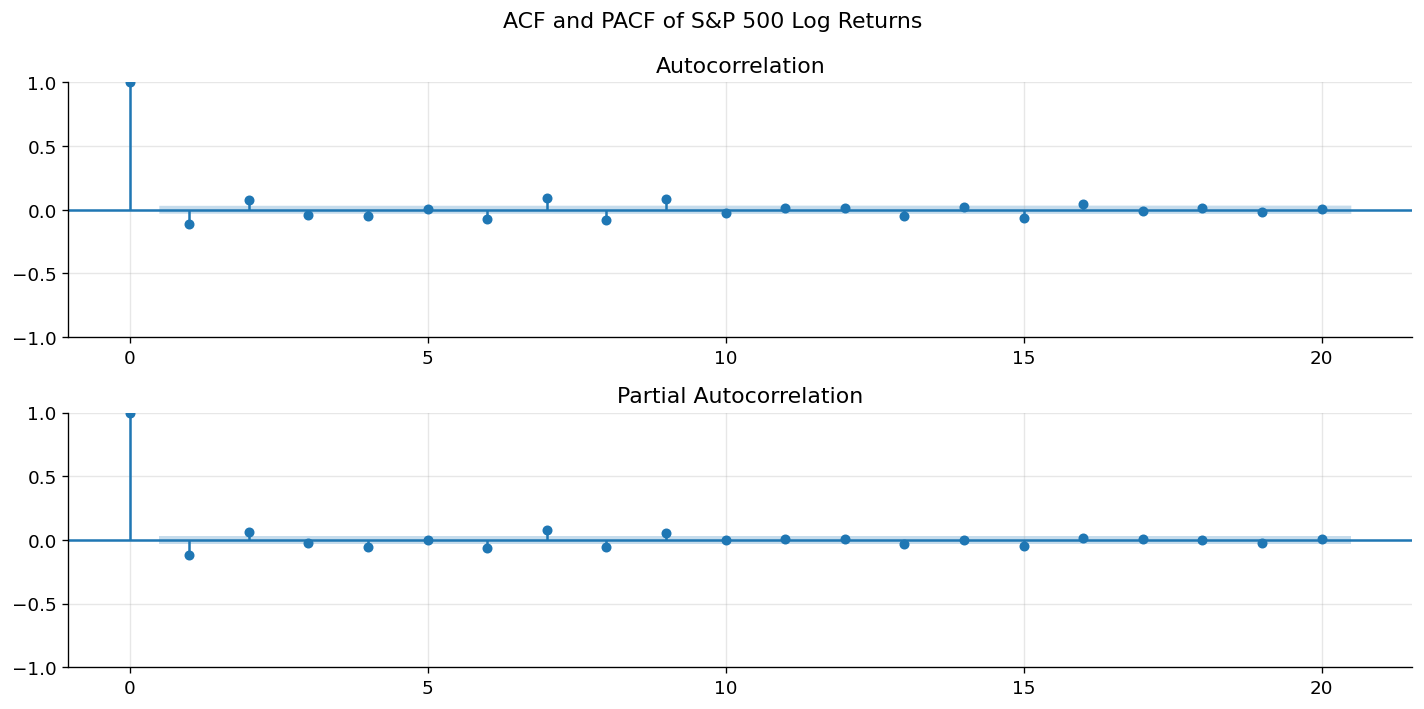

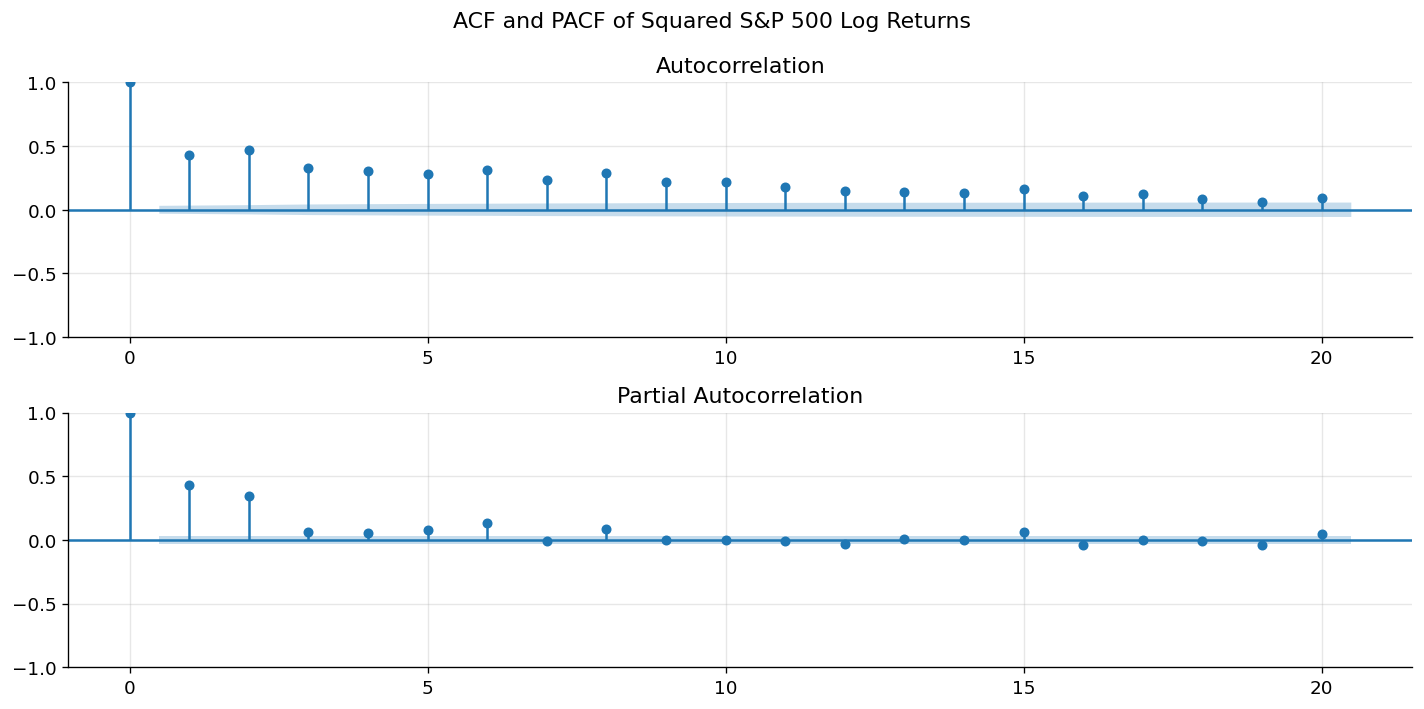

In [93]:
#ACF and PACF plots for data and squared data
plt.figure(figsize=(12, 6))
plt.suptitle('ACF and PACF of S&P 500 Log Returns')
plt.subplot(2, 1, 1)
plot_acf(Train_set, ax=plt.gca(), lags=20)
plt.subplot(2, 1, 2)
plot_pacf(Train_set, ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.suptitle('ACF and PACF of Squared S&P 500 Log Returns')
plt.subplot(2, 1, 1)
plot_acf(Train_set**2, ax=plt.gca(), lags=20)
plt.subplot(2, 1, 2)
plot_pacf(Train_set**2, ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()


We can observe that there is no autocorrelation and partial autocorellation in our training set. However there are visually present autocorrelation and partial autocorellation in the squares of our training set. This implies that we are dealing with **GARCH** effect. In the next step we will fit **GARCH(1,1)** to our data - as a exercise says us to do. However the PACF plot suggest that we should also consider **GARCH(2,1)**.

## Fitting **GARCH(1,1)**

Just to remind, the $X_t$ is the GARCH(1,1) process if 
$$
X_t = \sigma_t Z_t
$$ \
$$
\sigma_t^2 = \omega + \alpha X_{t-1}^2 + \beta \sigma_{t-1}^2 
$$ \
where $Z_t$ is a white noise process, $\omega > 0$, $\alpha \geq 0$, $\beta \geq 0$. 

In [94]:
#fitting GARCH(1,1) model
model_garch = arch_model(Train_set, vol='Garch', p=1, q=1)
model_garch_fit = model_garch.fit(disp='off')
print(model_garch_fit.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5173.24
Distribution:                  Normal   AIC:                           10354.5
Method:            Maximum Likelihood   BIC:                           10379.7
                                        No. Observations:                 4011
Date:                Fri, Apr 24 2026   Df Residuals:                     4010
Time:                        12:45:06   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0752  1.202e-02      6.256  3.952e-10 [5.

We see that coofiecents of fitted model are pretty certain. Furthermore this **GARCH(1,1)** is stationary because \
 $\alpha + \beta < 1$. Now we illustrate the conditional volatility obtain via our model for training dataset.

## Conditional volatility

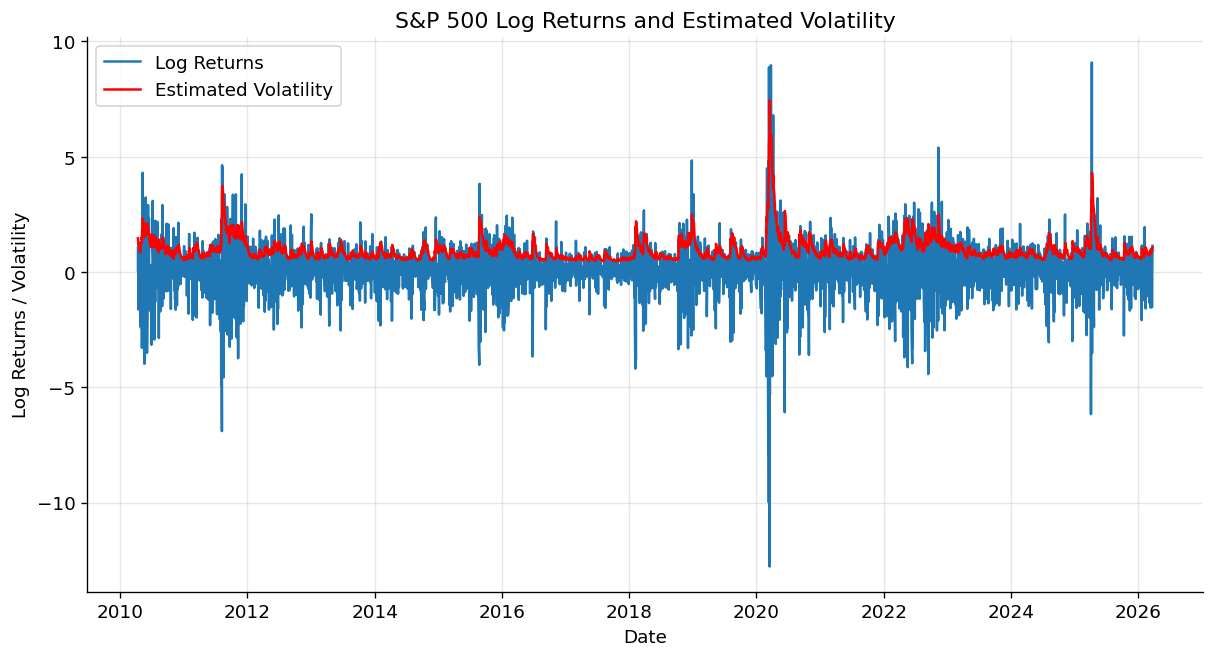

In [95]:
#ilustrate in sample volatility
plt.figure(figsize=(12, 6))
plt.plot(Train_set.index, Train_set, label='Log Returns')
plt.plot(Train_set.index, model_garch_fit.conditional_volatility, label='Estimated Volatility', color='red')
plt.title('S&P 500 Log Returns and Estimated Volatility')
plt.xlabel('Date')
plt.ylabel('Log Returns / Volatility')
plt.legend()
plt.grid(True)  
plt.show()

We see that calculated volatility suits well to actual data. Now we analyse the standardized residuals of obtained model.

## Standardized residuals

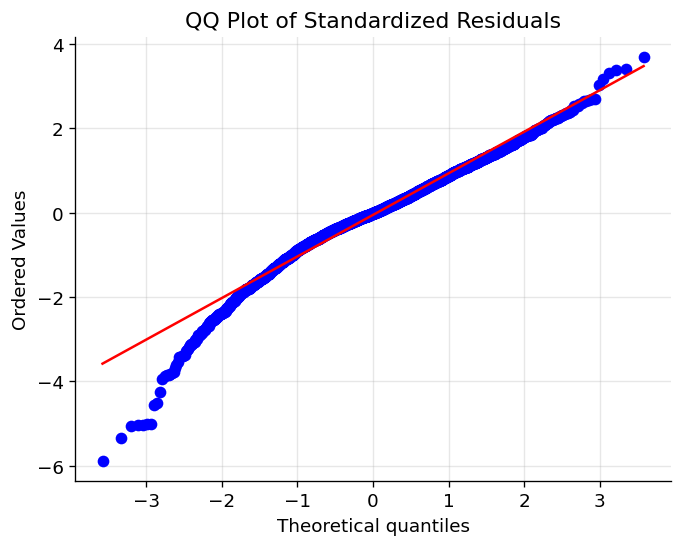

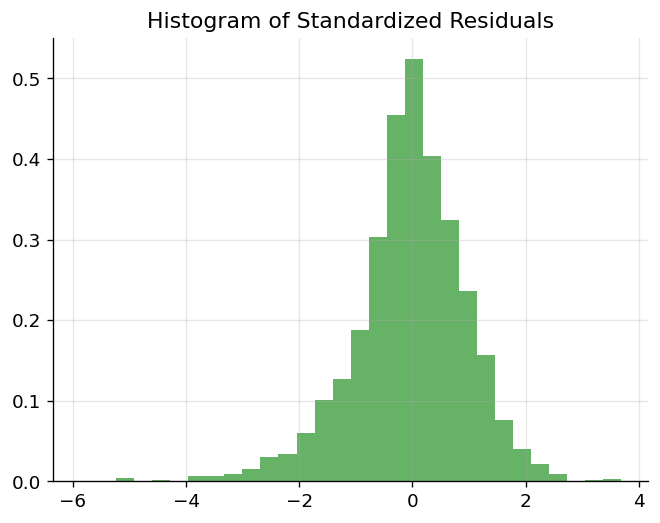

In [96]:
#analyze standarized residuals of GARCH model
standardized_residuals = model_garch_fit.resid / model_garch_fit.conditional_volatility
stats.probplot(standardized_residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Standardized Residuals')
plt.grid(True)
plt.show()

plt.hist(standardized_residuals, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Standardized Residuals')     
plt.grid(True)
plt.show()   



Both, q-q plot and density histogram shows us that the distribution of $Z_t$ in our model is left hand skewed. What is more the q-q plot gives us strong visual evidence that the left tail is heavier comparing to normal case. Those facts suggest that the GJR-GARCH would be better choise to our data. This model is capable of capturing asymmetric volatility in financial time series, specifically the "leverage effect"— where negative shocks increase volatility more than positive shocks. In summary our $Z_t$ is not normal.

## 20 days forecast - model validation

Now we perform the 20 days long volatility forecast. 

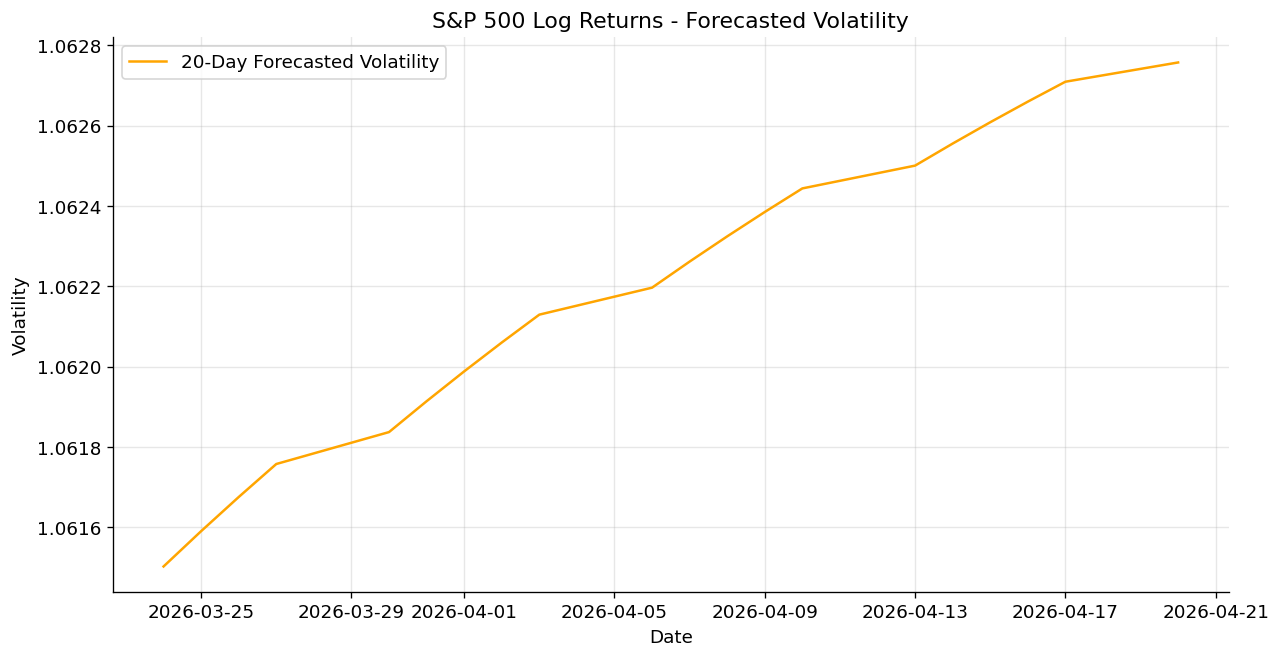

In [97]:
# 20 days forecast of volatility vs test set
garch_forecast = model_garch_fit.forecast(horizon=20)
plt.figure(figsize=(12, 6))
forecast_index = pd.date_range(start=Train_set.index[-1] + pd.Timedelta(days=1), periods=20, freq='B')
plt.plot(forecast_index, np.sqrt(garch_forecast.variance.values[-1]), label='20-Day Forecasted Volatility', color='orange')
plt.title('S&P 500 Log Returns - Forecasted Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

We see that our model predicted the slowly increasing volatility for several days. Now we compare this resoult with the absolute value of training dataset.

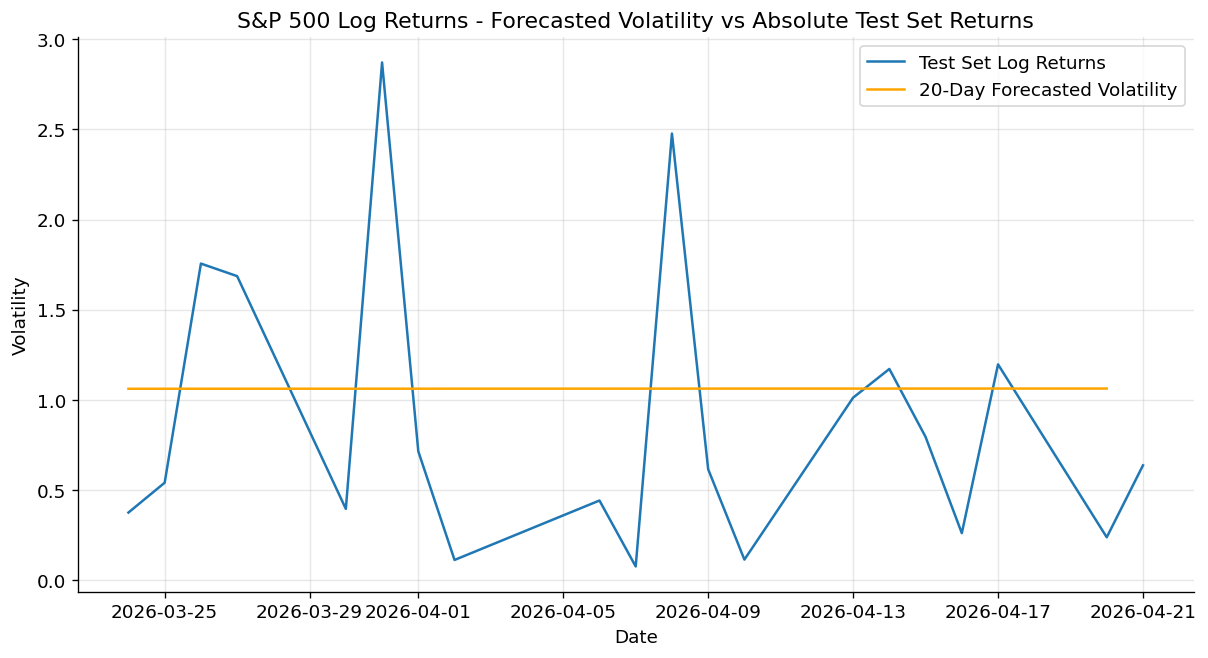

Average Forecasted Volatility: 1.0622
Average Absolute Test Set Returns: 0.8742


In [98]:
# 20 days forecast of volatility vs test set
garch_forecast = model_garch_fit.forecast(horizon=20)
plt.figure(figsize=(12, 6))
plt.plot(Test_set.index, np.abs(Test_set), label='Test Set Log Returns')
forecast_index = pd.date_range(start=Train_set.index[-1] + pd.Timedelta(days=1), periods=20, freq='B')
plt.plot(forecast_index, np.sqrt(garch_forecast.variance.values[-1]), label='20-Day Forecasted Volatility', color='orange')
plt.title('S&P 500 Log Returns - Forecasted Volatility vs Absolute Test Set Returns')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

#avg comparison of forecasted volatility and absolute test set returns
avg_forecasted_volatility = np.mean(np.sqrt(garch_forecast.variance.values[-1]))
avg_absolute_test_returns = np.mean(np.abs(Test_set))
print(f'Average Forecasted Volatility: {avg_forecasted_volatility:.4f}')
print(f'Average Absolute Test Set Returns: {avg_absolute_test_returns:.4f}')

The predicted volatility is rather constant comparing to the absolute value of training dataset. However the mean values of both are preety close to each other. Now we compare predicted volatility with the Garman-Kloas volatility estimator for training dataset.

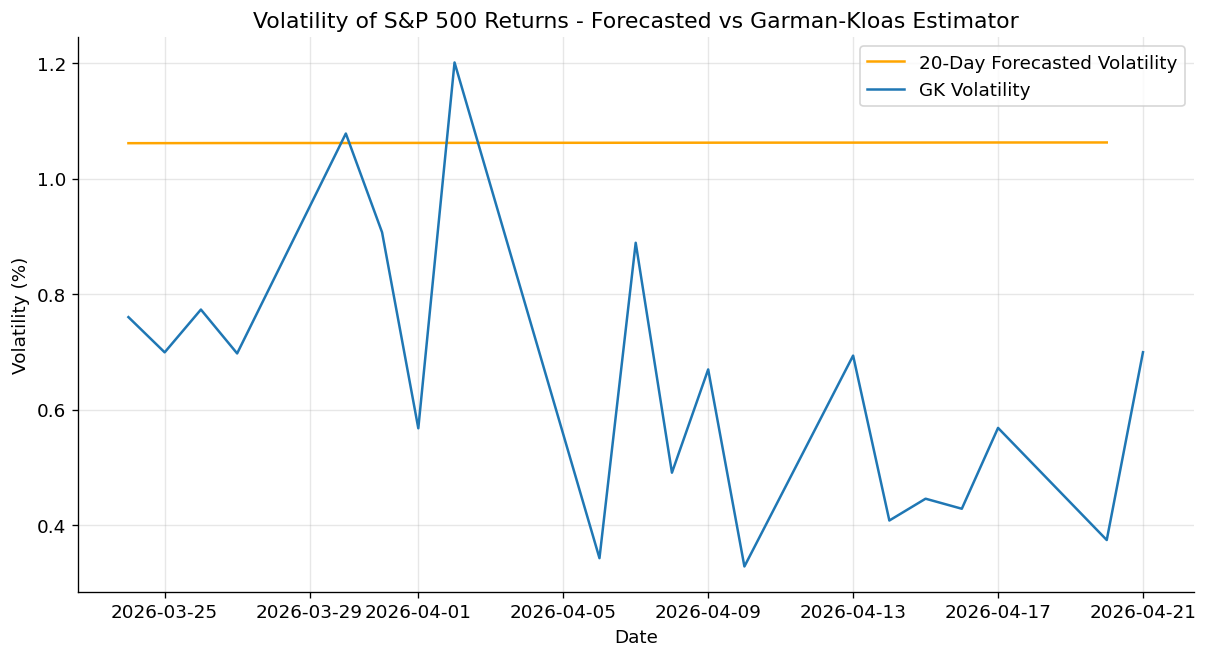

Average Forecasted Volatility: 1.0622
Average GK Volatility: 0.6512


In [99]:
#actual volatility calculated using Garman-Kloas estimator
High = SP500_prices['High'].iloc[-test_set_elements:]
Low = SP500_prices['Low'].iloc[-test_set_elements:]
Open = SP500_prices['Open'].iloc[-test_set_elements:]
Close = SP500_prices['Close'].iloc[-test_set_elements:]

GK_volatility = 100 *np.sqrt(0.5 * (np.log(High/Low) )**2 - (2 * np.log(2) - 1) * (np.log(Close/Open))**2)

plt.figure(figsize=(12, 6))
plt.plot(forecast_index, np.sqrt(garch_forecast.variance.values[-1]), label='20-Day Forecasted Volatility', color='orange')
plt.plot(Test_set.index, GK_volatility, label='GK Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.title('Volatility of S&P 500 Returns - Forecasted vs Garman-Kloas Estimator')
plt.legend()
plt.grid(True)
plt.show()

#avg comparison of forecasted volatility and GK volatility
avg_GK_volatility = np.mean(GK_volatility)
print(f'Average Forecasted Volatility: {avg_forecasted_volatility:.4f}')
print(f'Average GK Volatility: {avg_GK_volatility:.4f}')

Once again we can observe that the predicted volatility is rather constant comparing to the Garman-Kloas volatility estimator for training dataset. However in this case the mean value of our prediction is higher than estimated value for almost every day.

As a conclusion we state that fitted **GARCH(1,1)** is rather to simple to effectively model our data.